In [1]:
import numpy as np
import math
import pandas as pd
import cv2
import os
import re
import tqdm
from scipy.io import loadmat
from pdf2image import convert_from_path

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from PIL import Image
import pytesseract

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import backend as K

#from utils import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam, SGD
from keras.layers import *

from keras.applications import MobileNetV2
from keras.applications import InceptionResNetV2

from keras.models import Model
from keras.models import model_from_json

from keras.models import load_model

from ultralytics import YOLO
import difflib # for fuzzy logic for closest match between strings


In [243]:
def all_boxes(pred_bom):
    
    boxes_list = []
    boxes_other_list = []
    #pred_bom = cv2.imread(pred_bom_id)
    pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)

    x_pil = Image.fromarray(pred_bom_gray)
    display(x_pil)

    ##thresholding the image to a binary image
    thresh,img_bin = cv2.threshold(pred_bom_gray,0,255,cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    #x_pil = Image.fromarray(img_bin)
    #display(x_pil)

    #inverting the image 
    img_bin_invert = 255-img_bin

    #img_pil = Image.fromarray(img_bin_invert)
    #display(img_pil) 

    #print(pred_bom_gray.shape[1], ',', img_bin.shape[1], ',', img_bin_invert.shape[1])
      
    # Length(width) of kernel as 100th of total width
    #kernel_len = pred_bom_gray.shape[1]//100

    # added on 19/3/2025
    kernel_len = 25

    ## Defining a vertical kernel to detect all vertical lines of image 
    ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_len))

    # Defining a horizontal kernel to detect all horizontal lines of image
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    #Use vertical kernel to detect and save the vertical lines in a jpg
    image_1 = cv2.erode(img_bin_invert, ver_kernel, iterations=3)
    vertical_lines = cv2.dilate(image_1, ver_kernel, iterations=3)
    #x_pil = Image.fromarray(vertical_lines)
    #display(x_pil)

    #Use horizontal kernel to detect and save the horizontal lines in a jpg
    image_2 = cv2.erode(img_bin_invert, hor_kernel, iterations=3)
    horizontal_lines = cv2.dilate(image_2, hor_kernel, iterations=3)
    #x_pil = Image.fromarray(horizontal_lines)
    #display(x_pil)
    
    # Combine horizontal and vertical lines in a new third image, with both having same weight.
    img_vh = cv2.addWeighted(vertical_lines, 0.5, horizontal_lines, 0.5, 0.0)
    #x_pil = Image.fromarray(img_vh)
    #display(x_pil)

    # A kernel of 2x2
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    #print('Final kernel = ', kernel)

    img_vh_d = cv2.dilate(img_vh, kernel, iterations=2)

    #img_vh_d_pil = Image.fromarray(img_vh_d)
    #display(img_vh_d_pil)

    # Defining the cell boxes of img_vh

    contours_1, hierarchy = cv2.findContours(img_vh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes_other = np.zeros((len(contours_1), 4))

    for i in range(len(contours_1)):
    
        cnt = contours_1[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes_other[i, 0] = x
        boxes_other[i, 1] = y
        boxes_other[i, 2] = w
        boxes_other[i, 3] = h
    
    boxes_other_list.append(boxes_other)
    # Defining the cell boxes

    contours, hierarchy = cv2.findContours(img_vh_d, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes = np.zeros((len(contours), 4))

    for i in range(len(contours)):
    
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes[i, 0] = x
        boxes[i, 1] = y
        boxes[i, 2] = w
        boxes[i, 3] = h

    # print(len(boxes))
        
    boxes_list.append(boxes)
    
    return boxes_list, boxes_other_list, img_vh, img_vh_d   ## in format x, y, w, h. and boxes list is the list of horizontal lines in between 
                                            ## all vertical lines.


In [236]:
## For a valid box, same y value should appear at least 3 times for 'Sl.No.', 'Qty' and 'Description' columns.
## Also no y value of '0' is considered for valid boxes.

def filter_arrays(array_list):
    filtered_list = []  # List to store filtered arrays

    for arr in array_list:
        # Ensure the array is not empty
        if arr.size == 0:
            continue

        # Step 1: Identify y-values appearing at least 3 times
        y_values = arr[:, 1]
        unique_y, counts = np.unique(y_values, return_counts=True)

        # Keep only y-values appearing at least 3 times
        valid_y_values = {y for y, c in zip(unique_y, counts) if c >= 3}

        # Filter rows with these valid y-values
        filtered_arr = np.array([row for row in arr if row[1] in valid_y_values])

        # Step 2: Find the last occurrence of y = 0
        if filtered_arr.size > 0:
            last_zero_index = np.where(filtered_arr[:, 1] == 0)[0]
            if last_zero_index.size > 0:
                last_zero_index = last_zero_index[-1]  # Last occurrence index
                filtered_arr = filtered_arr[last_zero_index + 1:]  # Keep rows after

        # Add to the final list only if it's non-empty
        if filtered_arr.size > 0:
            filtered_list.append(filtered_arr)  # Corrected the append operation

    return filtered_list  # Return the list of filtered arrays

In [266]:
def find_bottom_left_one_rev(bom_boxes, pred_bom):
    """
    Find the bottom-most left-most box containing '1'
    """

    boxes_1 = filter_arrays(bom_boxes)
    boxes = sorted(boxes_1[0], key=lambda b: (b[1], b[0]))  # Sort by y (bottom-first), then x (left-first)
    #print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
    #print(boxes)
    # Convert list of arrays into a NumPy array
    boxes_np = np.array(boxes)

    # Step 1: Find the minimum x-value, excluding y=0
    #valid_boxes = boxes_np[boxes_np[:, 1] > 0]  # Keep only boxes with y > 0
    #min_x = np.min(valid_boxes[:, 0])  # Get minimum x
    min_x = np.min(boxes_np[:, 0])  # Get minimum x

    # Step 2: Get all boxes with this min_x value
    #filtered_boxes = valid_boxes[valid_boxes[:, 0] == min_x]
    filtered_boxes = boxes_np[boxes_np[:, 0] == min_x]
    
    for box in filtered_boxes:
        
        x, y, w, h = map(int, box)  # Convert to int
        
        x_c = x + 2
        y_c = y + 2
        w_c = w - 4
        h_c = h - 4
        pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
        roi = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]  # Crop the region - increase of x,y and reduction of w,h is very 
        #important for text accuracy
        sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
        roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
        _, cell_bin = cv2.threshold(roi_sharp, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
        text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()  # OCR
        #print('text =', text)
        if text == '1':
            return (x, y, w, h)  # Return coordinates of this box
    
    return None  # If not found

def draw_horizontal_line_if_needed(pred_bom, x, y, w, h):
    """
    Check if the longest horizontal line below the given box has another such line below it.
    If not, draw a new horizontal line at the bottom of the image.

    :param image_path: Path to the input image
    :param x, y, w, h: Coordinates of the bottom-most-left-most box containing "1"
    :return: Modified image
    """
    
    # Convert image to grayscale
    image = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
    
    # Apply binary threshold
    _, img_bin = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # Invert image (white background, black lines)
    img_bin_inv = 255 - img_bin
    
    # Define horizontal kernel
    kernel_len = image.shape[1] // 100
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    # Extract horizontal lines
    hor_lines = cv2.erode(img_bin_inv, hor_kernel, iterations=3)
    hor_lines = cv2.dilate(hor_lines, hor_kernel, iterations=3)

    #img_pil = Image.fromarray(hor_lines)
    #display(img_pil)
    #print('=============================================================')
    # Find contours of horizontal lines
    contours, _ = cv2.findContours(hor_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert contours to (x, y, w, h) format
    hor_lines_list = [cv2.boundingRect(cnt) for cnt in contours]

    # Sort lines based on the y-coordinate (bottom-most first)
    hor_lines_list = sorted(hor_lines_list, key=lambda x: x[1], reverse=True)
    #print(hor_lines_list)
    #print('=============================================================')

    # Find the longest horizontal line immediately below this box
    # Find the smallest y-value that is greater than y
    filtered_values = [item for item in hor_lines_list if item[1] > y]

    # Get the entry with the minimum y-value
    if filtered_values:
        longest_line = min(filtered_values, key=lambda x: x[1]) 
    #print(longest_line)
    #print('=============================================================')
        
    if longest_line:
        x_longest, y_longest, w_longest, _ = longest_line

        # Check if another horizontal line exists below it with equal or greater width
        for x_line, y_line, w_line, h_line in hor_lines_list:
            if y_line > y_longest and w_line >= w_longest:
                print("A longer or equal horizontal line exists below. No need to draw a new line.")
                return pred_bom  # No need to draw a new line

        # If no such line exists, draw a new horizontal line
        #print("No longer horizontal line found. Drawing a new line at the bottom.")
        # img_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        img_height, img_width = pred_bom.shape[:2]
        y_new_line = img_height - 2 # two pixel above the bottom edge
        cv2.line(pred_bom, (0, y_new_line), (img_width, y_new_line), (0, 0, 0), 2)
        
        return pred_bom

    else:
        # print("No horizontal line found below the given box.")
        return pred_bom  # No modifications needed
    

In [273]:
## Take out header boxes and all other box info for all items separately :

def header_and_item(pred_bom_corrected):
    
    bom_boxes_first,_,_,_ = all_boxes(pred_bom_corrected)
    bom_boxes = filter_arrays(bom_boxes_first)
    #print(bom_boxes)
    #print(type(bom_boxes))

    for i in range(len(bom_boxes)):   # for single bom drawings, len(bom_boxes) is always 1

        if i == 0:
            col_count_list = []
            header_boxes_list = []
            bom_boxes_list = []
            item_index_width_list = []

        #boxes_1 = bom_boxes[i][1:]   ## removing the line of full box i.e. removing 0th row
        #boxes_1_original = remove_before_last_zero(bom_boxes)
        #boxes_1 = boxes_1_original[0]
        boxes_1 = bom_boxes[0]
        
        ## Find number of columns i.e. max occurance of any y value :

        y_list = boxes_1[:, 1].tolist()   ## since boxes are in x,y,w,h format (output from cv2.boundingRect)

        col_count_array = np.bincount(y_list)  ## no. of occurances of each y-value
        col_count = col_count_array.max()  ## max. no. of occurances of any one y-value

        #print('No. of columns = ', col_count)
        

        # Now find the Header row :

        # In drawings, header row is always at the bottom.
        # Output of cv2.boundingRect always starts with the box of complete BOM
        # After this 1st row, the output starts with the bottom_most_right_most (in this order) box details.

        # So, y value of boxes[1] is the bottom_most-right_most (in this order) cell y value.

        y_bmrm_cell = boxes_1[0][1]  # y value of 1st bottom most cell

        # If occurances of this y value of 1st bottom most cell = number of columns, then this is the y value of Header Row

        num_col = y_list.count(y_bmrm_cell)   ## no. of occurances of y_bmrm_cell value 

        if num_col == col_count:
    
            y_header_row = y_bmrm_cell
            item_index_width = boxes_1[col_count-1, 2]  # This is the width of the 1st column i.e. 'Item No.' column
            bom_boxes_1 = boxes_1[1:]   ## remove 1st header row for bom consideration
    
        else:
        
            y_next_cell = boxes_1[1][1]

            num_col = y_list.count(y_next_cell)

            if num_col == col_count:
    
                y_header_row = y_next_cell
                item_index_width = boxes_1[col_count, 2]
                bom_boxes_1 = boxes_1[2:]    ## remove 1st 2 rows for bom consideration

        header_boxes = boxes_1[boxes_1[:, 1] == y_header_row] #######*************#########
    
        bom_boxes = bom_boxes_1[bom_boxes_1[:, 1] != y_header_row]
        
        col_count_list.append(col_count)
        item_index_width_list.append(item_index_width)
        header_boxes_list.append(header_boxes)
        bom_boxes_list.append(bom_boxes)
    
    return col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list  ## all boxes in x, y, w, h format


In [260]:
# Function to standardize column names using difflib
def standardize_headers(df, reference_headers):
    standardized_cols = {
        col: difflib.get_close_matches(col, reference_headers, n=1, cutoff=0.6)[0] if difflib.get_close_matches(col, reference_headers, n=1, cutoff=0.6) else col
        for col in df.columns
    }
    return df.rename(columns=standardized_cols)


In [274]:
def bom_df_rev(pred_bom_id):

    pred_bom = cv2.imread(pred_bom_id)

    if pred_bom is None:
        print("Error: Image not found or could not be loaded.")
        return None, None, None

    boxes_list, _, _, _ = all_boxes(pred_bom)
    #print(boxes_list)
    #print('======================================================================')
    #x, y, w, h = find_bottom_left_one_rev(boxes_list, pred_bom)
    #print(x, y, w, h)

    result = find_bottom_left_one_rev(boxes_list, pred_bom)
    if result:  # Check if function returned a valid box
        x, y, w, h = result
        #print(x, ',', y, ',', w, ',', h)
    else:
        print("No suitable box found")

    # Run function and get modified image
    pred_bom_corrected = draw_horizontal_line_if_needed(pred_bom, x, y, w, h)
    
    print('=========================== ALL OK ABOVE THIS ============================')
    # Extract header and item details
    col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list = header_and_item(pred_bom_corrected)
    #gridless_bom_image, left_margin = remove_grid_lines(pred_bom_id)
    print(bom_boxes_list)
    # Ensure we have header boxes
    if not header_boxes_list or len(header_boxes_list) == 0:
        #print("Error: No header boxes found!")
        return None, None, None

    # Extract header column widths
    width_list = header_boxes_list[0][:, 2]  
    x_list = header_boxes_list[0][:, 0]
    #print('width list = ', width_list)
    # Find the frequency of column widths
    width_frequency = np.unique(width_list, return_counts=True)[1]  
    #print('Width Frequency:', width_frequency)

    # Get all column widths from BOM items
    all_width_list = bom_boxes_list[0][:, 2].tolist()
    row_count_array = np.bincount(all_width_list)  
    row_count_apparent = row_count_array.max()
    
    # Estimate row count
    row_count = row_count_apparent // np.max(width_frequency) if np.max(width_frequency) != 0 else 0
    #print('Estimated Row Count:', row_count)

    sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
    # Extract header text
    header_text = []
    for box in header_boxes_list[0]:  
        x, y, w, h = map(int, box)  # Convert to integers
        #header_crop = pred_bom[y:y+h, x:x+w]

        x_c = x + 2
        y_c = y + 2
        w_c = w - 4
        h_c = h - 4
        pred_bom_gray = cv2.cvtColor(pred_bom_corrected, cv2.COLOR_BGR2GRAY)
        roi = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]  # Crop the region - increase of x,y and reduction of w,h is very 
        #important for text accuracy
        roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
        
        #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
        text = pytesseract.image_to_string(roi_sharp, config='--psm 6 --oem 3').strip()  # OCR
        text = text.replace("\n", " ")  # Remove newlines ***** added on 20/3/2025
        header_text.append(text)

    header_text.append('drg_id')
    #header_text = [text.replace("\n", " ").strip() for text in header_text]  # Remove newlines ***** added on 20/3/2025 
    serialised_header_text = header_text[::-1]  # Reverse order
    print('****** UPTO Header Text ALL OK *******')
    # Extract BOM items
    bom_text = []
    for i, bom_boxes in enumerate(bom_boxes_list):
        y_unique = np.unique(bom_boxes[:, 1])[::-1]  # Reverse order
        #print('===================================================================')
        #print(y_unique)
        #print(col_count_list, '++', col_count_list[0])
        #print('===================================================================')
        for j in y_unique:
            bom_sub_text = []
            aa = np.ones((col_count_list[0], 4))  
            bb = bom_boxes[bom_boxes[:, 1] == j]  # Select only rows with matching Y
            
            #print('=== j ==', j)
            #print('length aa =', len(aa), 'aa shape = ', aa.shape, 'length bb =', len(bb), 'bb shape = ', bb.shape)
            #print('+++++++++++++++++++++++++++++++++++++++++++++++++++++')
            #print(bb)
            #print('+++++++++++++++++++++++++++++++++++++++++++++++++++++')
            #print("width_list = ", width_list)
            #print("x_list = ", x_list)
            for k in range(len(aa)):
                for l in range(len(bb)):
                    #print('value of k = ', k, 'x_list[k] = ', x_list[k])
                    #print('value of l = ', l, 'bb[l] = ', bb[l])
                    
                    if abs((bb[l][2] + bb[l][0]) - (width_list[k] + x_list[k])) <= 2:
                        aa[k, :] = bb[l, :]
                #print('========================== CHANGE OG K =============================')
            #print(aa)
            #print('CHECH-1-+++++++++++++++++++++++++++++++++++++++++++++++++++++')
            for k in range(len(aa)):
                x, y, w, h = map(int, aa[k])
                #print(x, ',', y, ',', w, ',', h)
                #print('CHECK-2-++++++++++++++++++++++++++++++++++++++++++++++++++++')

                if x == 1 and y == 1 and w == 1 and h == 1:
                   text = ' '  
                else:
                    x_c = x + 2
                    y_c = y + 2
                    w_c = w - 4
                    h_c = h - 4

                    cell_crop_image = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]

                    if cell_crop_image is None or cell_crop_image.size == 0:
                        print("Error: cell_crop_image is empty or not loaded correctly.")

                    # Find the first column where any value < 10
                    col_indices = np.where(np.any(cell_crop_image < 10, axis=0))[0]  # Get all matching column indices

                    if col_indices.size > 0:  # Check if any column meets the condition
                        col_index = col_indices[0]  # First column where condition is met
                        start_col = max(0, col_index - 3)  # Keep 3 columns before
                        modified_arr = cell_crop_image[:, start_col:]
                        #print(f"Original Shape: {cell_crop_image.shape}")
                        #print(f"New Shape: {modified_arr.shape}")
                    else:
                        modified_arr = cell_crop_image  # Keep the original array unchanged

                    # OCR text extraction
                    cell_crop_sharp = cv2.filter2D(modified_arr, -1, sharp_kernel)
                    _, cell_bin = cv2.threshold(cell_crop_sharp, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        
                    #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
                    text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()  # OCR
                    #print("=================================================================================================")
            
                    text = text.replace("\n", " ")  # Remove newlines within extracted text
                    #if x == 248 and y == 409 and w ==  694 and h == 59:
                    
                # OCR text extraction
                #text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()
                #text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 1 -c tessedit_char_whitelist=0123456789').strip()
                bom_sub_text.append(text)

            bom_id = ((pred_bom_id.split('/'))[-1].split('.'))[0] # making bom df with only drg no. and not with drg. path
            bom_sub_text.append(bom_id)  # Append image ID
            bom_text.append(bom_sub_text[::-1])  # Reverse order

    # Convert to DataFrame
    expected_cols = len(header_text)  # Expected column count
    filtered_bom_text = [row for row in bom_text if len(row) == expected_cols]

    # Convert to DataFrame
    df = pd.DataFrame(filtered_bom_text, columns=serialised_header_text)

    #df = pd.DataFrame(bom_text, columns=serialised_header_text)
    return df, bom_text, bom_sub_text


In [322]:
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-002-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-003-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-005-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-006-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1023.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1111.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg" 
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1114.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1141.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-04-02-Model-page-001.jpg"

#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"

#pred_bom_id = "/Users/subrata/Desktop/project_2_jpg/cropped_bom_jpg/2JR406-02-05-Model-page-001.jpg"
pred_bom_id = "/Users/subrata/Desktop/project_2_jpg/cropped_bom_jpg/2JR406-02-06-Model-page-001.jpg"
#pred_bom_id = "/Users/subrata/Desktop/project_3_pdf/cropped_bom_jpg/1789072R0_MAIN_FRAME_ASSEMBLY_crop_0.jpg"


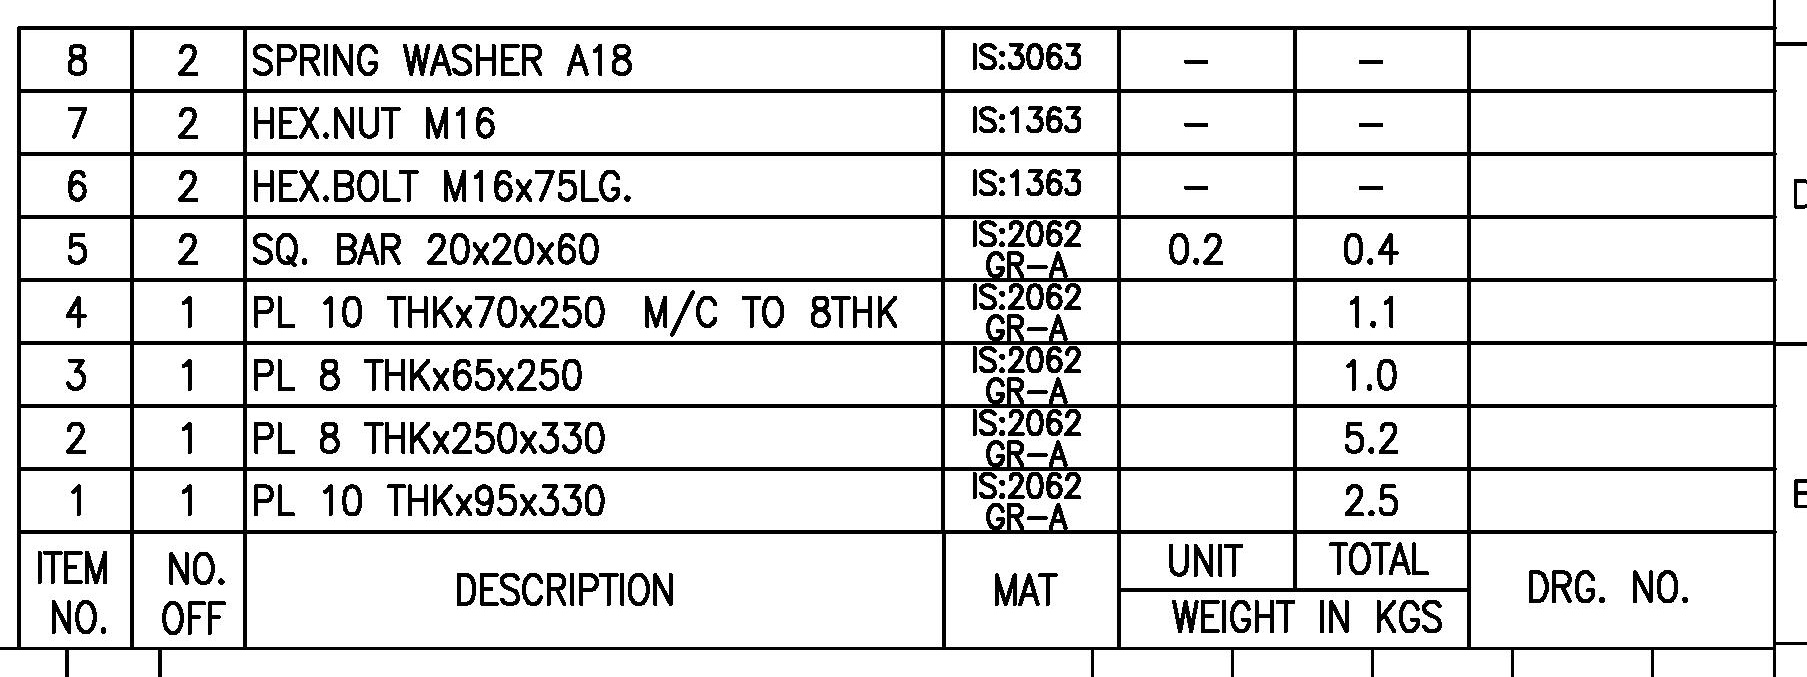

A longer or equal horizontal line exists below. No need to draw a new line.
=========================== ALL OK ABOVE THIS ============================


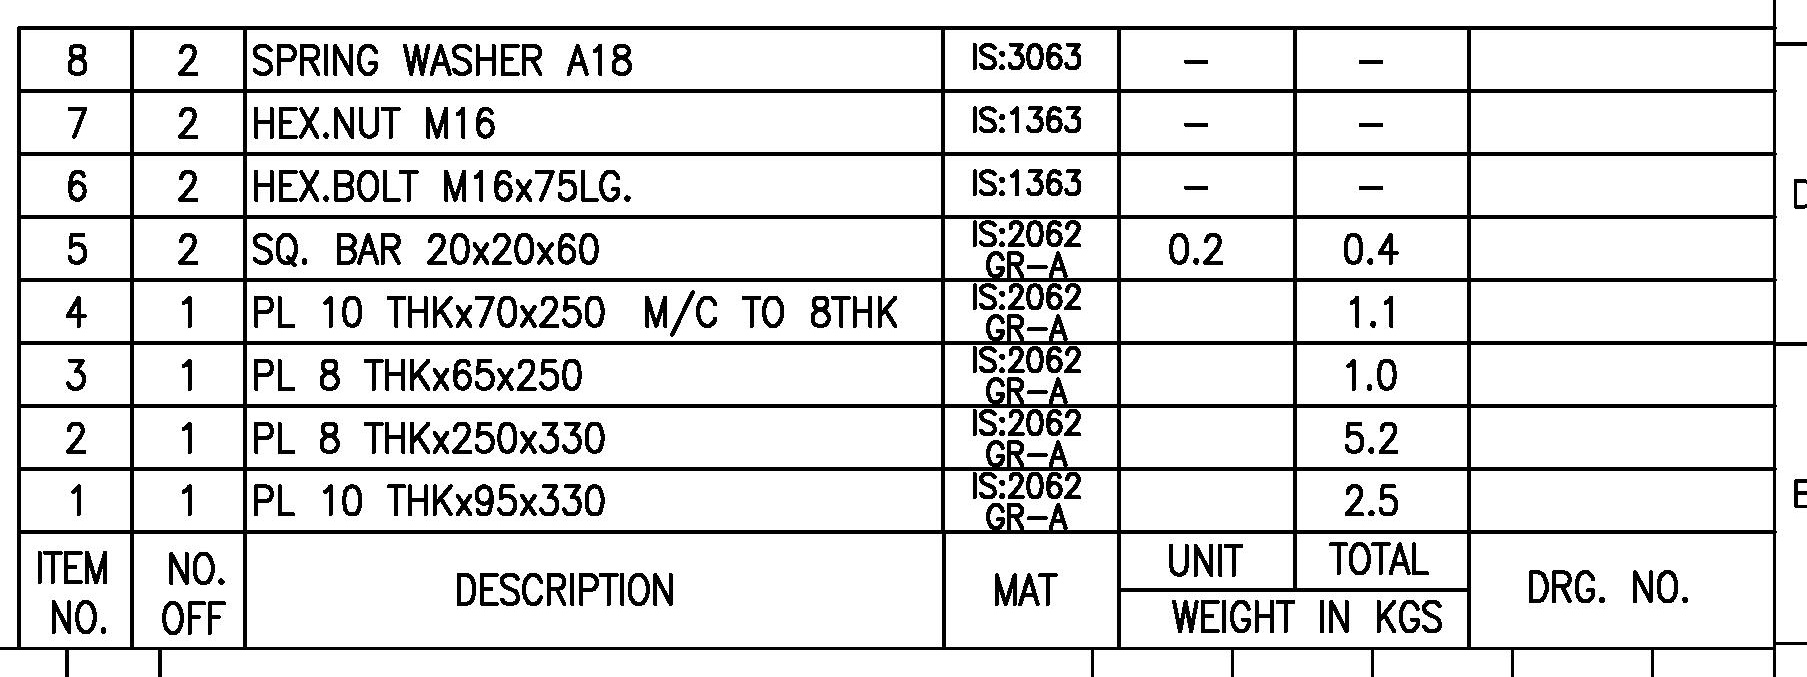

[array([[       1472,         472,         302,          59],
       [       1298,         472,         170,          59],
       [       1122,         472,         172,          59],
       [        946,         472,         172,          59],
       [        248,         472,         694,          59],
       [        135,         472,         109,          59],
       [         22,         472,         109,          59],
       [       1472,         409,         302,          59],
       [       1298,         409,         170,          59],
       [       1122,         409,         172,          59],
       [        946,         409,         172,          59],
       [        248,         409,         694,          59],
       [        135,         409,         109,          59],
       [         22,         409,         109,          59],
       [       1472,         346,         302,          59],
       [       1298,         346,         170,          59],
       [       1122,   

In [323]:
df,_,_ = bom_df_rev(pred_bom_id)

In [324]:
df.head(20)

,drg_id,ITEM NO.,NO. OFF,DESCRIPTION,MAT,UNIT,TOTAL,DRG. NO.
0,2JR406-02-06-Model-page-001,1,1,PL 10 THKx95x330,:Z002Z GR-A,| |,2.5,|
1,2JR406-02-06-Model-page-001,2,1,PL 8 THKx250x330,1:2002 GR-—A,Po,5.2,ST
2,2JR406-02-06-Model-page-001,3,1,PL 8 THKx65x250,>: 2002 CR-A,,1.0,eT
3,2JR406-02-06-Model-page-001,4,1,PL 10 THKx70x250 M/C TO 8THK,I: 2002 GR=-A,,1.1,eT
4,2JR406-02-06-Model-page-001,5,2,SQ. BAR 20x20x60,I>: 2002 GR-A,0.2,0.4,|
5,2JR406-02-06-Model-page-001,6,2,HEX.BOLT M16x75LG.,IS:1563,,,|
6,2JR406-02-06-Model-page-001,7,2,HEX.NUT M16,IS:1363,,,|
7,2JR406-02-06-Model-page-001,8,2,SPRING WASHER A18,IS:3065,,,|


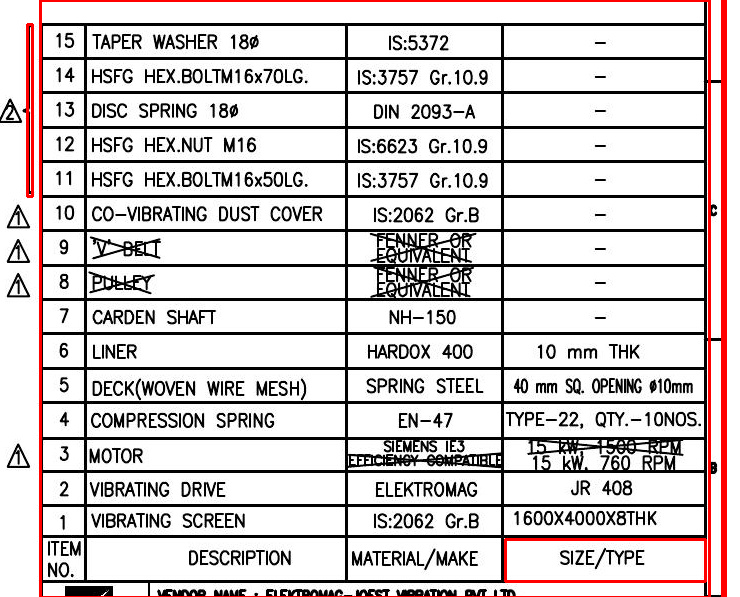

In [17]:
x, y, w, h = 27,          24,           5,         172  # Example values
#print(x, y, w, h)
x1, y1, w1, h1 = 722,           0,           3,         597
x2, y2, w2, h2 = 40,           0,         669,         597
x3, y3, w3, h3 = 505,         539,         200,          42

#x1, y1, w1, h1 = 896, 453,  38,  38

x_c = x + 2
y_c = y + 2
w_c = w - 4
h_c = h - 4

pred_bom = cv2.imread(pred_bom_id)
pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
#roi = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c] 


# Draw a red rectangle (BGR format: (0, 0, 255))
cv2.rectangle(pred_bom, (x, y), (x + w, y + h), (255, 0, 0), 2)
cv2.rectangle(pred_bom, (x1, y1), (x1 + w1, y1 + h1), (255, 0, 0), 2)
cv2.rectangle(pred_bom, (x2, y2), (x2 + w2, y2 + h2), (255, 0, 0), 2)
cv2.rectangle(pred_bom, (x3, y3), (x3 + w3, y3 + h3), (255, 0, 0), 2)


x_pil = Image.fromarray(pred_bom)
display(x_pil)

Original Shape: (55, 690)
New Shape: (55, 689)


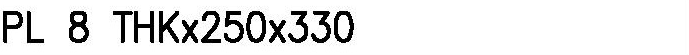

In [47]:
# Find the first column where any value < 10
col_indices = np.where(np.any(roi < 10, axis=0))[0]  # Get all matching column indices

if col_indices.size > 0:  # Check if any column meets the condition
        col_index = col_indices[0]  # First column where condition is met
        start_col = max(0, col_index - 3)  # Keep 3 columns before
        modified_arr = roi[:, start_col:]
        print(f"Original Shape: {roi.shape}")
        print(f"New Shape: {modified_arr.shape}")
else:
        modified_arr = roi  # Keep the original array unchanged

x_pil = Image.fromarray(modified_arr)
display(x_pil)

In [48]:
 # OCR text extraction
sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
cell_crop_sharp = cv2.filter2D(modified_arr, -1, sharp_kernel)
_, cell_bin = cv2.threshold(cell_crop_sharp, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        
#text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()  # OCR
print(text)

PL 8 THKx250x330


In [ ]:
folder_name = input("Enter folder name: ")
drg_folder = f"/Users/subrata/Desktop/{folder_name}/"

#Extract only bom part of the drawings :
output_cropped_folder = extract_bom(drg_folder)

# Path to the folder containing images
folder_path = output_cropped_folder # Change this to your folder path

# List to store DataFrames
df_list = []

# Loop through all images in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith((".jpg", ".png", ".jpeg")):  # Add other image formats if needed
        image_path = os.path.join(folder_path, file_name)

        df, _, _ = bom_df_rev(image_path)  # Call your function

        if df is not None:  # Ensure df is valid
            bom_id = ((image_path.split('/'))[-1].split('.'))[0] # making bom df with only drg no. and not with drg. path
            print('BOM Created for = ', bom_id)

            df_list.append(df)

if df_list:

    # Take the header of the first DataFrame as the reference
    reference_headers = df_list[0].columns.tolist()

    # Apply standardization to all DataFrames (excluding the first, as it's already correct)
    df_list = [df_list[0]] + [standardize_headers(df, reference_headers) for df in df_list[1:]]

    # Concatenate all DataFrames
    final_df = pd.concat(df_list, ignore_index=True)
    final_df = final_df.dropna(axis=1, how="all")  # Drop completely empty columns
    print('ALL BOM CREATED SUCCESSFULLY')

else:
    print("No valid DataFrames generated.")

#final_df.to_excel("/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/project_1.xlsx", index=False)  # Saves without the index column

# Define column indexes to sort by (e.g., 1st and 3rd columns)
sort_columns_1 = [final_df.columns[0]]  # Sort by 0th column
sort_columns_2 = [final_df.columns[3], final_df.columns[2]]  # Sort by 3rd and 2nd column

# Sort DataFrame
final_df_sorted_1 = final_df.sort_values(by=sort_columns_1, ascending=True)
final_df_sorted_2 = final_df.sort_values(by=sort_columns_2, ascending=True)

# Save both original and sorted DataFrame in the same Excel file
output_bom_file = drg_folder + "bill_of_material.xlsx"
#with pd.ExcelWriter("/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/project_1.xlsx") as writer:
with pd.ExcelWriter(output_bom_file) as writer:
    final_df_sorted_1.to_excel(writer, sheet_name="Original Data", index=False)
    final_df_sorted_2.to_excel(writer, sheet_name="Sorted Data", index=False)

print("Bill of Material file saved successfully with two sheets!")




In [4]:
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-002-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-003-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-005-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-006-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1023.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1111.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg" 
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1114.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1141.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
## below are error prone :
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg" *** ERROR ******
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-04-02-Model-page-001.jpg"


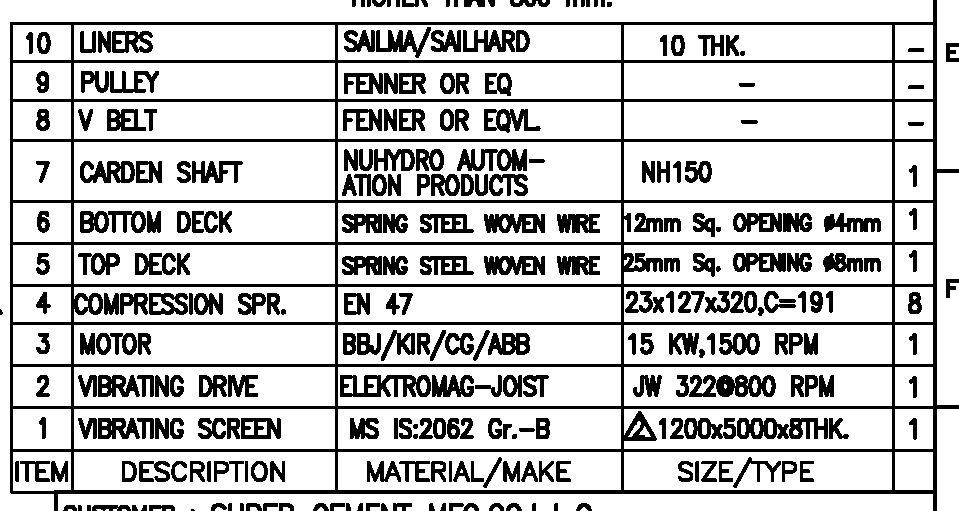

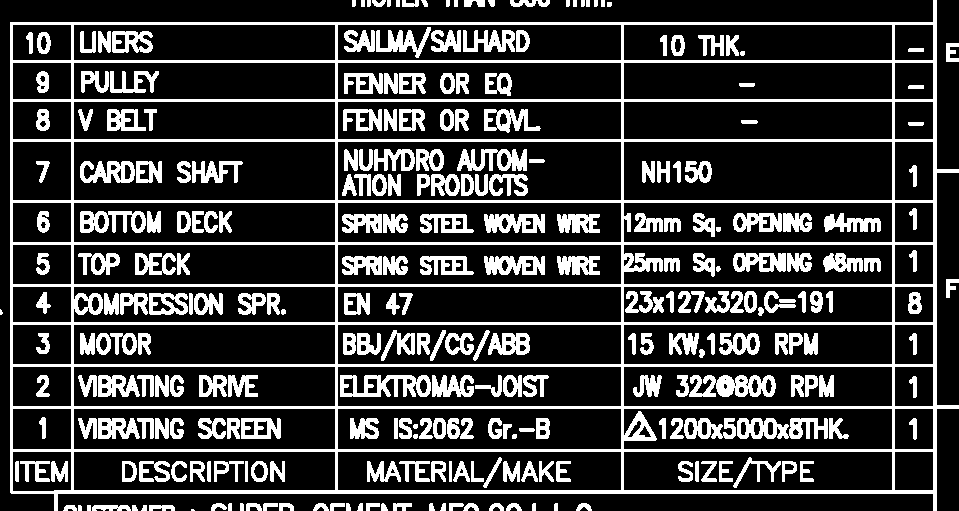

959 , 959 , 959


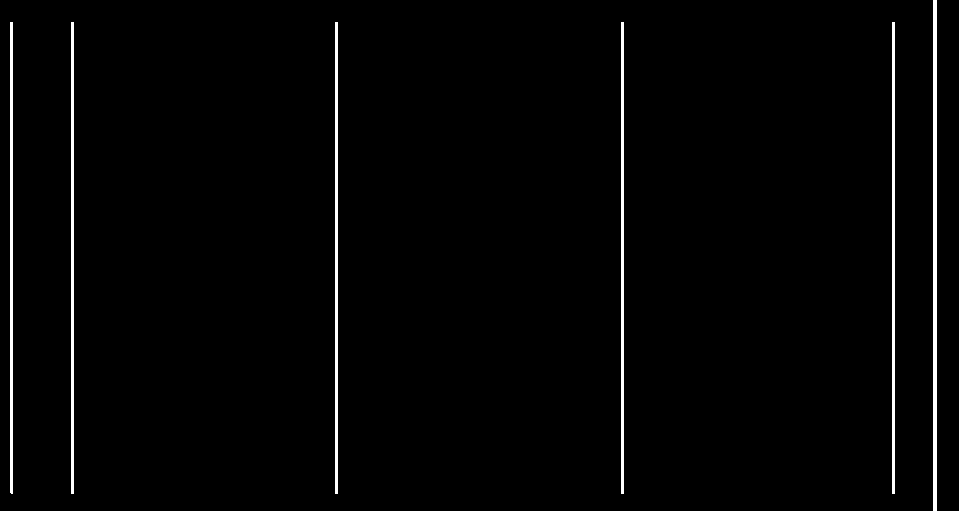

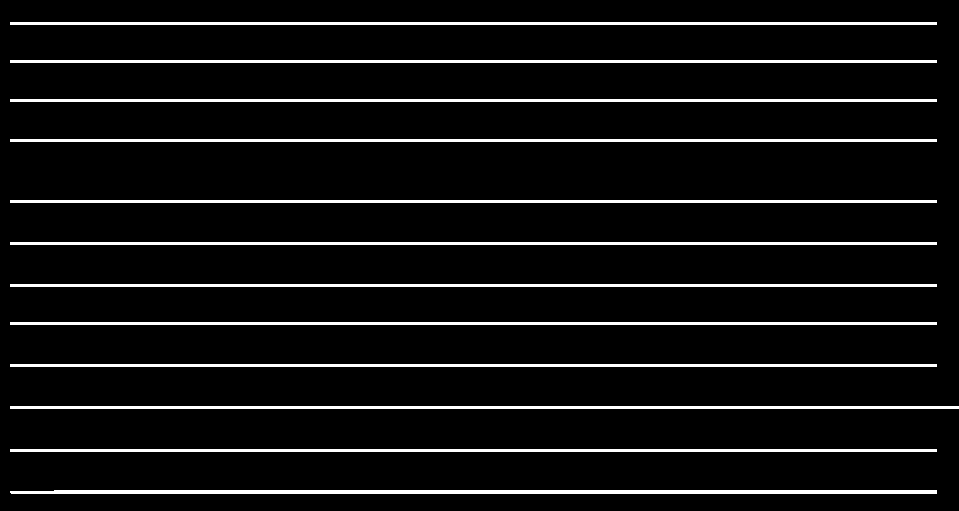

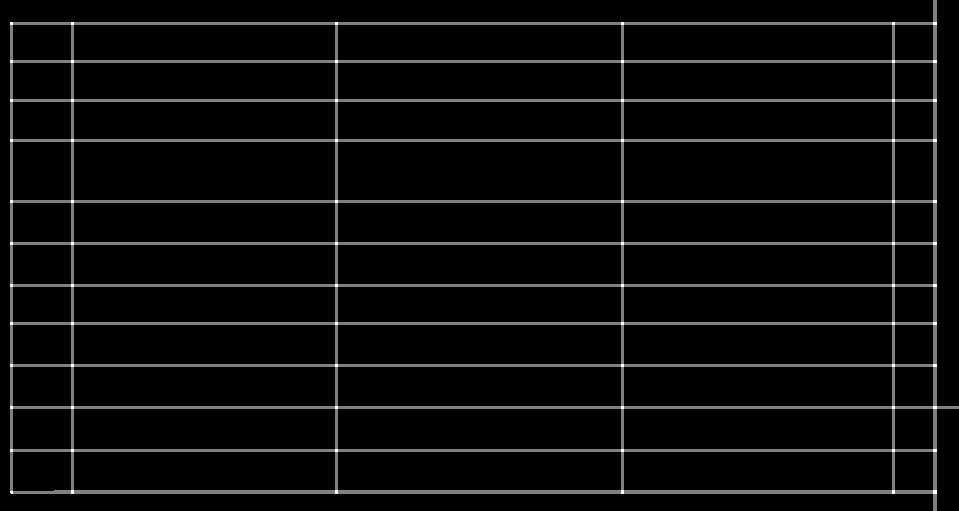

Final kernel =  [[1 1]
 [1 1]]


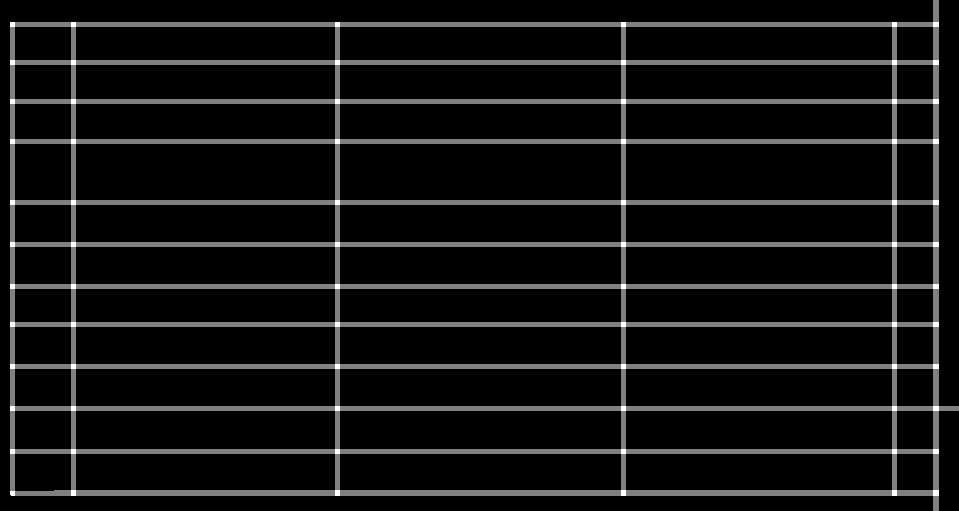

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
bom boxes are =  [array([[ 10.,   0., 949., 511.],
       [896., 453.,  38.,  38.],
       [625., 453., 268.,  38.],
       [339., 453., 283.,  38.],
       [ 75., 453., 261.,  38.],
       [ 14., 453.,  58.,  39.],
       [896., 410.,  38.,  40.],
       [625., 410., 268.,  40.],
       [339., 410., 283.,  40.],
       [ 75., 410., 261.,  40.],
       [ 14., 410.,  58.,  40.],
       [896., 368.,  38.,  39.],
       [625., 368., 268.,  39.],
       [339., 368., 283.,  39.],
       [ 75., 368., 261.,  39.],
       [ 14., 368.,  58.,  39.],
       [896., 326.,  38.,  39.],
       [625., 326., 268.,  39.],
       [339., 326., 283.,  39.],
       [ 75., 326., 261.,  39.],
       [ 14., 326.,  58.,  39.],
       [896., 288.,  38.,  35.],
       [625., 288., 268.,  35.],
       [339., 288., 283.,  35.],
       [ 75., 288., 261.,  35.],
       [ 14., 288.,  58.,  35.],
       [896., 246.,  38.,  39.],
       [625., 246., 268., 

In [22]:
pred_bom = cv2.imread(pred_bom_id)

if pred_bom is None:
        print("Error: Image not found or could not be loaded.")
    

## Find all boxes list i.e. the list of all horizontal lines in between all vertical lines :
bom_boxes, bom_boxes_other, img_vh, img_vh_d = all_boxes(pred_bom)
print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
print('bom boxes are = ', bom_boxes)
print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')

In [12]:
print('bom boxes other are = ', bom_boxes_other)

bom boxes other are =  [array([[ 10.,   0., 949., 511.],
       [894., 451.,  40.,  40.],
       [623., 451., 270.,  40.],
       [337., 451., 285.,  40.],
       [ 73., 451., 263.,  40.],
       [ 12., 451.,  60.,  41.],
       [894., 408.,  40.,  42.],
       [623., 408., 270.,  42.],
       [337., 408., 285.,  42.],
       [ 73., 408., 263.,  42.],
       [ 12., 408.,  60.,  42.],
       [894., 366.,  40.,  41.],
       [623., 366., 270.,  41.],
       [337., 366., 285.,  41.],
       [ 73., 366., 263.,  41.],
       [ 12., 366.,  60.,  41.],
       [894., 324.,  40.,  41.],
       [623., 324., 270.,  41.],
       [337., 324., 285.,  41.],
       [ 73., 324., 263.,  41.],
       [ 12., 324.,  60.,  41.],
       [894., 286.,  40.,  37.],
       [623., 286., 270.,  37.],
       [337., 286., 285.,  37.],
       [ 73., 286., 263.,  37.],
       [ 12., 286.,  60.,  37.],
       [894., 244.,  40.,  41.],
       [623., 244., 270.,  41.],
       [337., 244., 285.,  41.],
       [ 73., 244.,

10 0 949 511


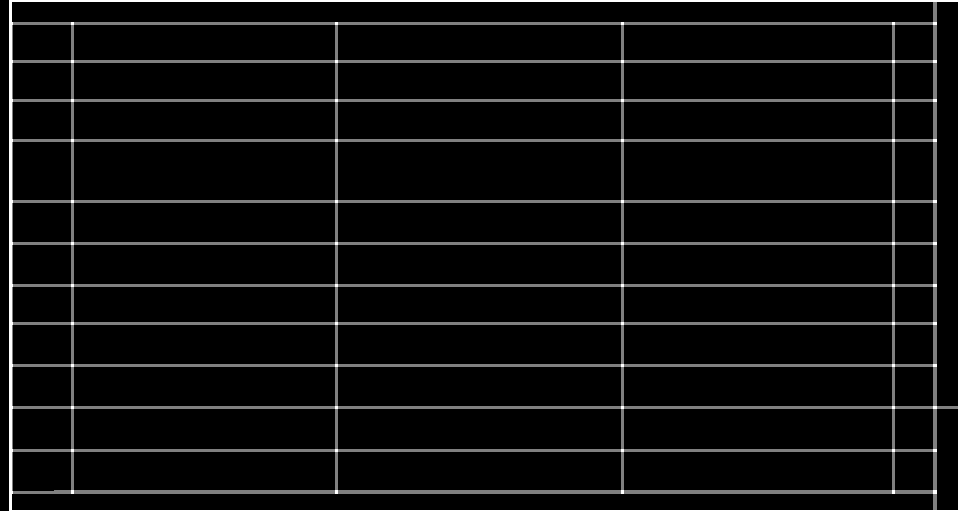

In [18]:

x, y, w, h = 10,   0, 949, 511  # Example values
print(x, y, w, h)

x1, y1, w1, h1 = 896, 453,  38,  38

# Draw a red rectangle (BGR format: (0, 0, 255))
cv2.rectangle(img_vh, (x, y), (x + w, y + h), (255, 0, 0), 2)
x_pil = Image.fromarray(img_vh)
display(x_pil)

In [24]:
output_vh = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/img_vh.jpg"
output_vh_d = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/img_vh_d.jpg"

cv2.imwrite(output_vh, img_vh)
cv2.imwrite(output_vh_d, img_vh_d)

True

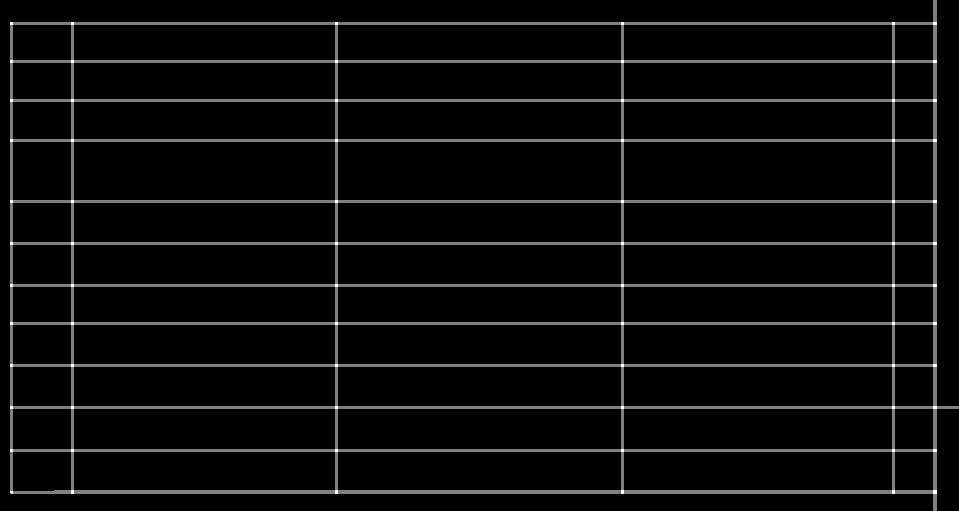

[array([[  0.,   0., 959., 511.],
       [334., 492.,   3.,   3.],
       [ 70., 492.,   3.,   3.],
       [336., 491.,   3.,   4.],
       [ 72., 491.,   3.,   4.],
       [335., 490.,   3.,   3.],
       [ 71., 490.,   3.,   3.],
       [  9., 490.,   5.,   4.],
       [932., 489.,   6.,   6.],
       [891., 489.,   5.,   6.],
       [620., 489.,   5.,   6.],
       [620., 489.,   3.,   3.],
       [336., 489.,   3.,   3.],
       [334., 489.,   3.,   3.],
       [ 72., 489.,   3.,   3.],
       [ 70., 489.,   3.,   3.],
       [ 11., 450.,   3.,   3.],
       [932., 448.,   6.,   5.],
       [891., 448.,   5.,   5.],
       [620., 448.,   5.,   5.],
       [334., 448.,   5.,   5.],
       [ 70., 448.,   5.,   5.],
       [  9., 448.,   4.,   4.],
       [ 11., 407.,   3.,   3.],
       [  9., 407.,   3.,   3.],
       [932., 405.,   6.,   5.],
       [891., 405.,   5.,   5.],
       [620., 405.,   5.,   5.],
       [334., 405.,   5.,   5.],
       [ 70., 405.,   5.,   5.],
       [ 

In [30]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/img_vh.jpg"
pred_bom = cv2.imread(pred_bom_id)
pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)

x_pil = Image.fromarray(pred_bom_gray)
display(x_pil)

boxes_new_list = []

# Invert the image (if needed)
img = 255 - pred_bom_gray 

# Find contours
contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

boxes_new = np.zeros((len(contours), 4))

for i in range(len(contours)):
    
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes_new[i, 0] = x
        boxes_new[i, 1] = y
        boxes_new[i, 2] = w
        boxes_new[i, 3] = h
    
boxes_new_list.append(boxes_new)

print(boxes_new_list)

0 0 959 511


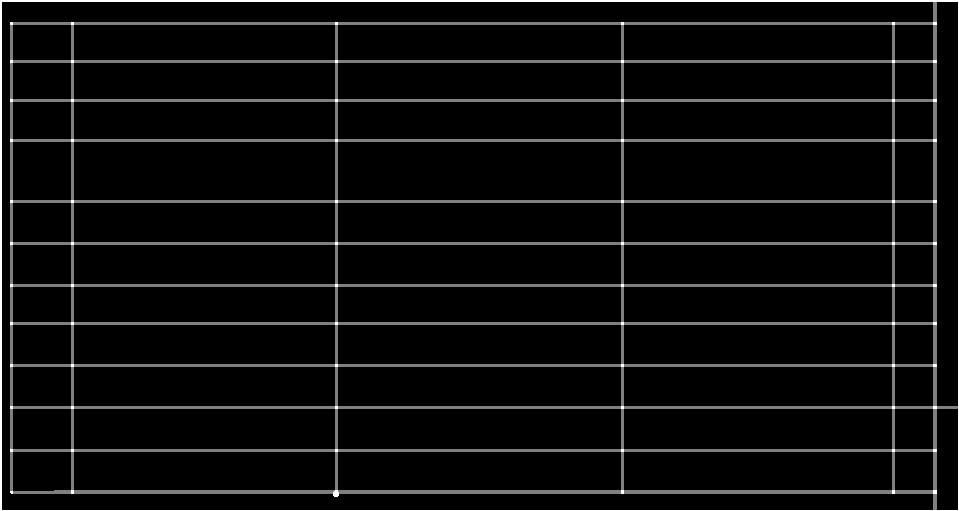

In [33]:
x, y, w, h = 0,   0, 959, 511  # Example values
print(x, y, w, h)

x1, y1, w1, h1 = 334, 492,   3,   3

# Draw a red rectangle (BGR format: (0, 0, 255))
cv2.rectangle(pred_bom_gray, (x, y), (x + w, y + h), (255, 0, 0), 2)
cv2.rectangle(pred_bom_gray, (x1, y1), (x1 + w1, y1 + h1), (255, 0, 0), 2)
x_pil = Image.fromarray(pred_bom_gray)
        
display(x_pil) 

In [35]:
! pip install mistralai


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from mistralai import MistralClient

ImportError: cannot import name 'MistralClient' from 'mistralai' (/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/mistralai/__init__.py)

In [37]:
! pip install --upgrade typing_extensions


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [38]:
from mistralai import MistralClient

ImportError: cannot import name 'MistralClient' from 'mistralai' (/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/mistralai/__init__.py)

In [2]:
!pip show mistralai

Name: mistralai
Version: 1.5.1
Summary: Python Client SDK for the Mistral AI API.
Home-page: 
Author: Mistral
Author-email: 
License: 
Location: /Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages
Requires: eval-type-backport, httpx, jsonpath-python, pydantic, python-dateutil, typing-inspect
Required-by: 


In [3]:
from mistralai.client import MistralClient

In [1]:
from mistralai import MistralClient

ImportError: cannot import name 'MistralClient' from 'mistralai' (/Users/subrata/.pyenv/versions/3.9.15/lib/python3.9/site-packages/mistralai/__init__.py)

In [2]:
from mistralai.client import MistralClient

In [4]:

import os
#os.environ['MISTRAL_API_KEY'] = '4aa83da4-f6b7-4d74-99bf-bf221237'

# Initialize the Mistral client
client = MistralClient(api_key=os.getenv('MISTRAL_API_KEY'))

NotImplementedError: This client is deprecated. To migrate to the new client, please refer to this guide: https://github.com/mistralai/client-python/blob/main/MIGRATION.md. If you need to use this client anyway, pin your version to 0.4.2.

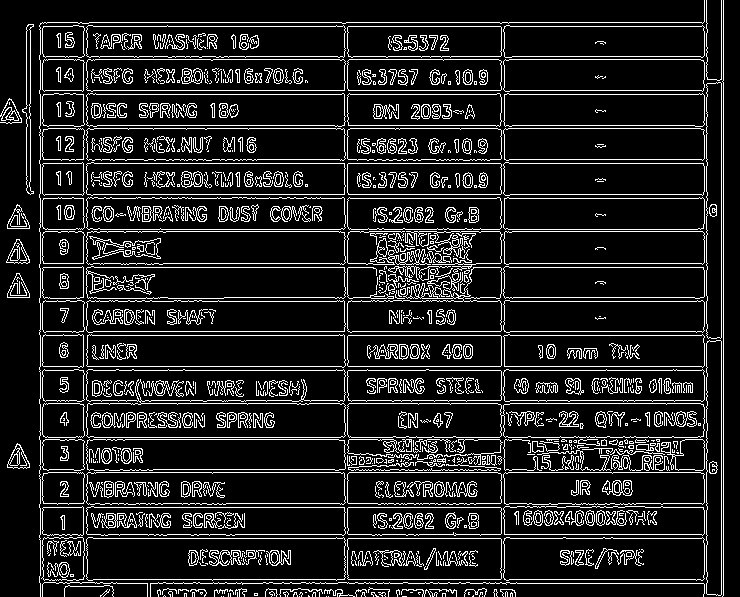

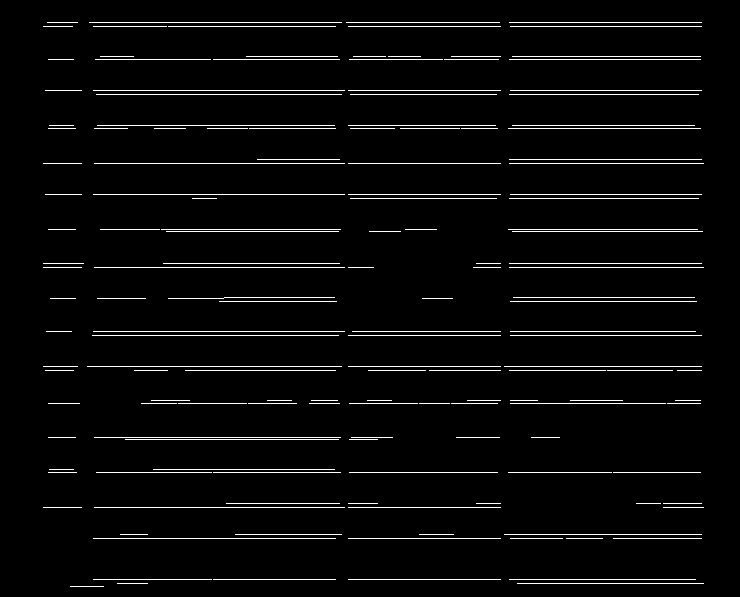

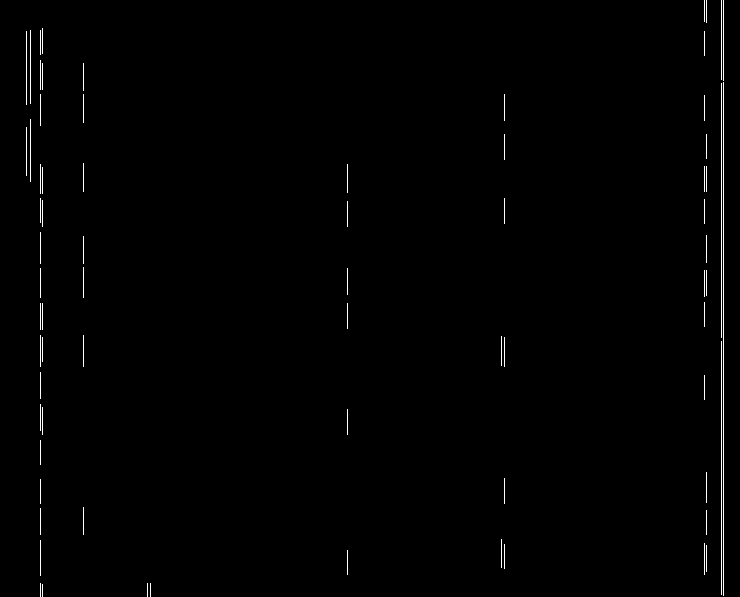

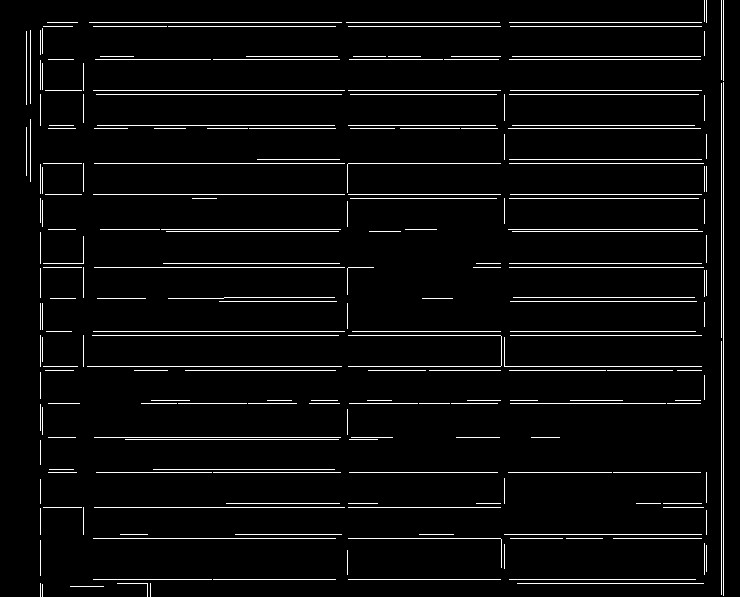

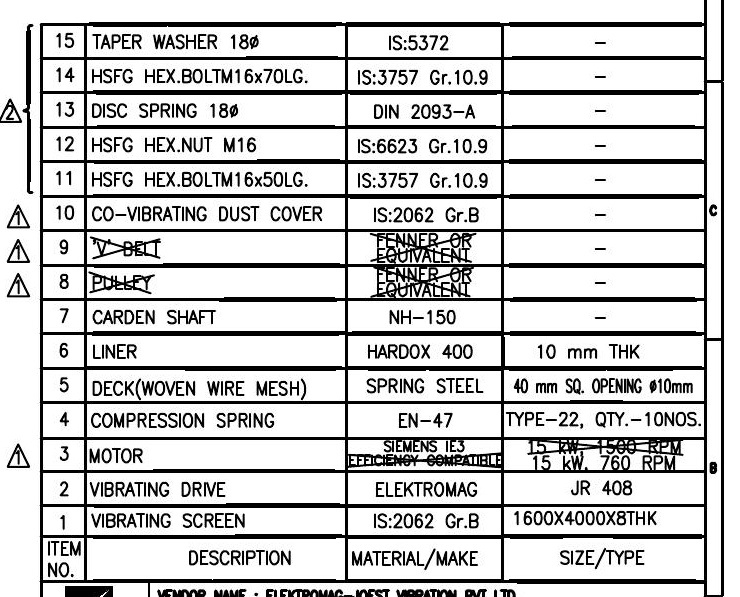

In [45]:
def remove_standalone_lines(image_path, output_path, min_length=50):
    # Load the image
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Edge detection
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    x_pil = Image.fromarray(edges)
    display(x_pil)

    # Define structuring elements for detecting horizontal and vertical lines
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))

    # Detect horizontal and vertical lines
    horizontal_lines = cv2.morphologyEx(edges, cv2.MORPH_OPEN, horizontal_kernel)
    vertical_lines = cv2.morphologyEx(edges, cv2.MORPH_OPEN, vertical_kernel)

    x_pil = Image.fromarray(horizontal_lines)
    display(x_pil)
    x_pil = Image.fromarray(vertical_lines)
    display(x_pil)

    # Combine detected lines
    combined_lines = cv2.bitwise_or(horizontal_lines, vertical_lines)

    x_pil = Image.fromarray(combined_lines)
    display(x_pil)

    # Find contours of the lines
    contours, _ = cv2.findContours(combined_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a mask to remove standalone lines
    mask = np.ones_like(gray) * 255

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > min_length or h > min_length:  # Keep long lines (table structure)
            cv2.drawContours(mask, [cnt], -1, (0, 0, 0), thickness=cv2.FILLED)

    # Remove standalone lines by applying the mask
    result = cv2.bitwise_and(image, image, mask=mask)

    # Save the processed image
    cv2.imwrite(output_path, result)

# Example usage:
input_image = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"  # Input image path
output_image = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171_filtered.jpg"  # Output image path

remove_standalone_lines(input_image, output_image)

out_put_image = cv2.imread(output_image)
x_pil = Image.fromarray(out_put_image)
display(x_pil)


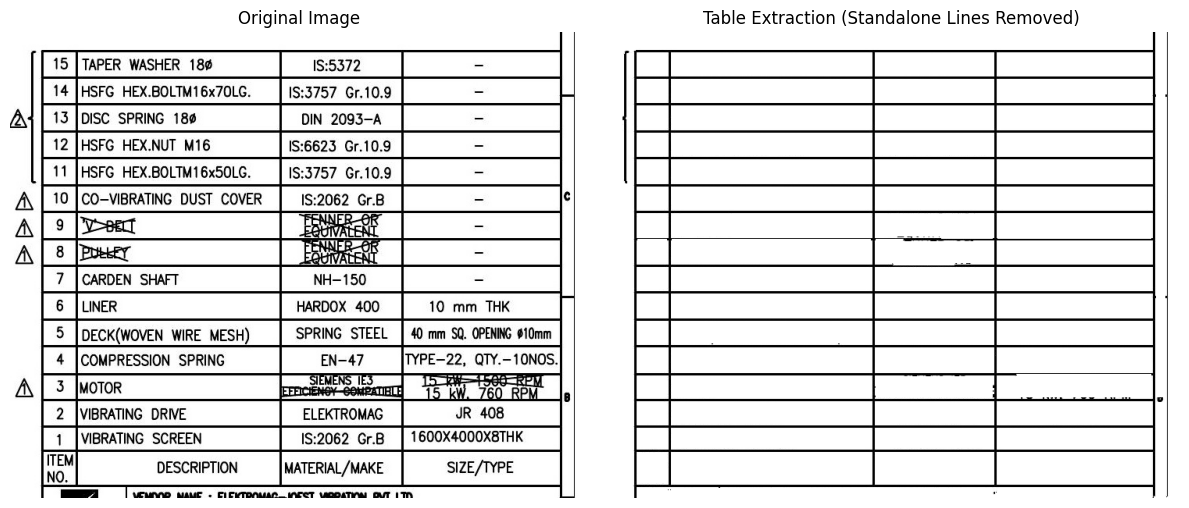

In [138]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_table_remove_standalone_lines(image_path, output_path=None):
    """
    Extracts tables from an image by removing standalone horizontal and vertical lines
    that don't intersect with other lines.
    
    Args:
        image_path (str): Path to the input image
        output_path (str, optional): Path to save the output image. If None, won't save.
    
    Returns:
        numpy.ndarray: Processed image with only the table lines
    """
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold to get binary image
    _, binary = cv2.threshold(gray, 30, 100, cv2.THRESH_BINARY_INV)
    
    # Create a copy for visualization
    result_img = img.copy()

    edges = cv2.Canny(binary, 100, 200, apertureSize=3)
    
    # Detect lines using Hough transform
    #lines = cv2.HoughLinesP(binary, rho=0.5, theta=np.pi/180, threshold=98, 
    #                        minLineLength=50, maxLineGap=10)
    
    lines = cv2.HoughLinesP(edges, rho=0.5, theta=np.pi/180, threshold=100, 
                           minLineLength=50, maxLineGap=10)
    
    if lines is None:
        print("No lines detected in the image.")
        return img
    
    # Create a blank image to draw the lines
    line_image = np.zeros_like(binary)
    
    # Draw all detected lines on the blank image
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1, y1), (x2, y2), 255, 2)
    
    # Find intersection points
    # Dilate the line image to make intersections more visible
    kernel = np.ones((3, 3), np.uint8)
    dilated_line_image = cv2.dilate(line_image, kernel, iterations=1)
    
    # Get line endpoints and midpoints for checking intersections
    line_data = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Calculate line orientation - 0 for horizontal, 1 for vertical, 2 for diagonal
        dx, dy = abs(x2 - x1), abs(y2 - y1)
        orientation = 2  # Default to diagonal
        if dx > 3*dy:  # Horizontal line
            orientation = 0
        elif dy > 3*dx:  # Vertical line
            orientation = 1
        
        line_data.append({
            'endpoints': ((x1, y1), (x2, y2)),
            'orientation': orientation,
            'has_intersection': False
        })
    
    # Check for intersections by looking at each line
    for i, line1 in enumerate(line_data):
        if line1['orientation'] == 2:  # Skip diagonal lines
            continue
            
        for j, line2 in enumerate(line_data):
            if i == j or line2['orientation'] == 2:  # Skip same line and diagonal lines
                continue
            
            # Only check horizontal vs vertical lines
            if line1['orientation'] == line2['orientation']:
                continue
                
            # Check if lines might intersect (simple bounding box check)
            (x1, y1), (x2, y2) = line1['endpoints']
            (x3, y3), (x4, y4) = line2['endpoints']
            
            x_min1, x_max1 = min(x1, x2), max(x1, x2)
            y_min1, y_max1 = min(y1, y2), max(y1, y2)
            
            x_min2, x_max2 = min(x3, x4), max(x3, x4)
            y_min2, y_max2 = min(y3, y4), max(y3, y4)
            
            # If bounding boxes overlap, there's potentially an intersection
            if (x_min1 <= x_max2 and x_max1 >= x_min2 and 
                y_min1 <= y_max2 and y_max1 >= y_min2):
                
                # Create small regions around potential intersection and check for line pixels
                if line1['orientation'] == 0:  # line1 is horizontal
                    x_intersect = max(x_min1, x_min2) if x_min2 > x_min1 else x_min1
                    y_intersect = max(y_min2, y_min1) if y_min1 > y_min2 else y_min2
                else:  # line1 is vertical
                    x_intersect = max(x_min2, x_min1) if x_min1 > x_min2 else x_min2
                    y_intersect = max(y_min1, y_min2) if y_min2 > y_min1 else y_min1
                
                # Check 5x5 area around potential intersection for line pixels
                intersection_region = dilated_line_image[
                    max(0, y_intersect-2):min(dilated_line_image.shape[0], y_intersect+3),
                    max(0, x_intersect-2):min(dilated_line_image.shape[1], x_intersect+3)
                ]
                
                # If the number of white pixels is high enough, it's likely an intersection
                if np.sum(intersection_region > 0) > 10:
                    line_data[i]['has_intersection'] = True
                    line_data[j]['has_intersection'] = True
    
    # Create an image with only table lines (lines with intersections)
    table_line_image = np.zeros_like(binary)
    
    for i, line_info in enumerate(line_data):
        if line_info['has_intersection'] or line_info['orientation'] == 2:  # Keep intersecting lines and diagonals
            (x1, y1), (x2, y2) = line_info['endpoints']
            cv2.line(table_line_image, (x1, y1), (x2, y2), 255, 2)
    
    # Create a colored result for visualization
    result_img = img.copy()
    # Create a mask for the table lines
    result_img[table_line_image == 0] = 255  # Set non-table parts to white
    
    # Save the result if output path is provided
    if output_path:
        cv2.imwrite(output_path, result_img)
    
    return result_img

def visualize_results(image_path):
    """
    Process the image and visualize the original and processed images side by side.
    
    Args:
        image_path (str): Path to the input image
    """
    # Read the original image
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    # Process the image
    processed = extract_table_remove_standalone_lines(image_path)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    
    # Display results
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(processed)
    plt.title('Table Extraction (Standalone Lines Removed)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Replace with your image path
    image_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"
    output_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171_filtered_c.jpg"
    
    # Option 1: Just process and save
    extract_table_remove_standalone_lines(image_path, output_path)
    
    # Option 2: Visualize the results
    visualize_results(image_path)

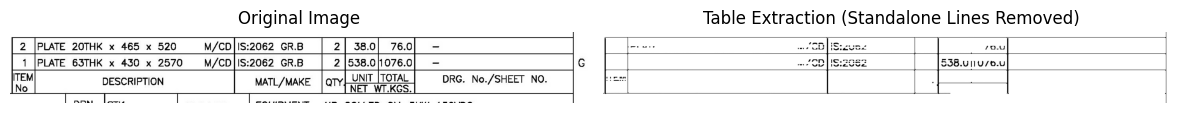

In [139]:
# Example usage
if __name__ == "__main__":
    # Replace with your image path
    image_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-003-23.jpg"
    
    output_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-003-23_filtered_c.jpg"
    
    # Option 1: Just process and save
    extract_table_remove_standalone_lines(image_path, output_path)
    
    # Option 2: Visualize the results
    visualize_results(image_path)

In [ ]:
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-002-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-003-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-005-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-006-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1023.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1111.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg" 
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1114.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1141.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
## below are error prone :
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-04-02-Model-page-001.jpg"

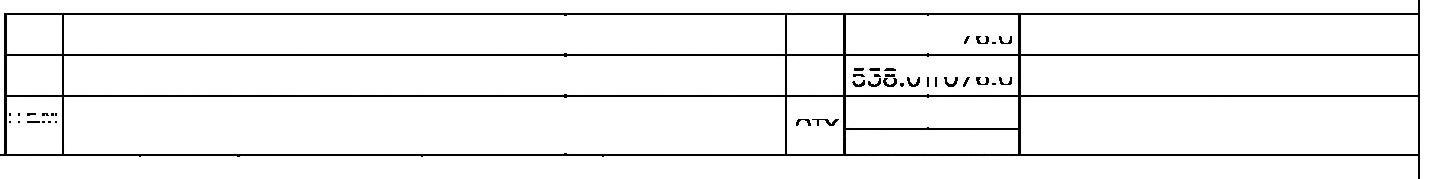

1456 , 1456 , 1456
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
bom boxes are =  [array([[          0,           0,        1422,         179],
       [        847,         131,         172,          24],
       [       1022,          98,         397,          57],
       [        847,          98,         172,          31],
       [        788,          98,          56,          57],
       [         65,          98,         721,          57],
       [          8,          98,          55,          57],
       [       1022,          57,         397,          39],
       [        847,          57,         172,          39],
       [        788,          57,          56,          39],
       [         65,          57,         721,          39],
       [          8,          57,          55,          39],
       [       1022,          16,         397,          39],
       [        847,          16,         172,          39],
       [        788,          16,          5

In [118]:
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171_filtered_c.jpg"

pred_bom = cv2.imread(output_path)

if pred_bom is None:
        print("Error: Image not found or could not be loaded.")
    

## Find all boxes list i.e. the list of all horizontal lines in between all vertical lines :
bom_boxes, _, _, _ = all_boxes(pred_bom)
print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
print('bom boxes are = ', bom_boxes)
print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')

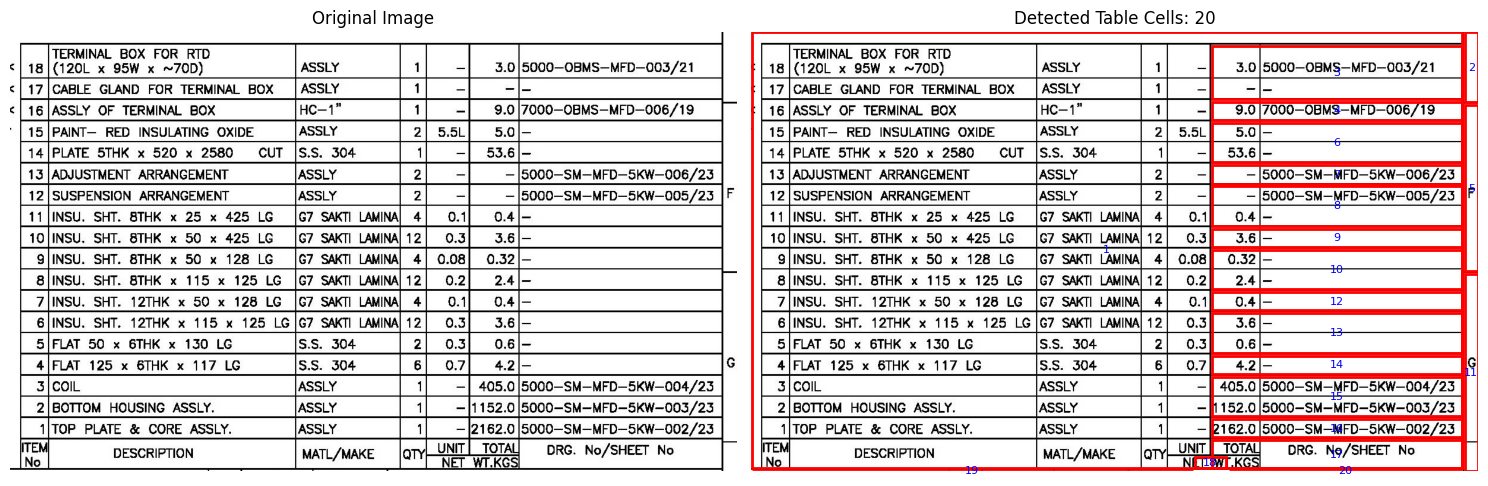

Found 20 cells in the table.
Cell coordinates (x, y, width, height):
Cell 1: (0, 0, 1197, 734)
Cell 2: (1202, 0, 22, 118)
Cell 3: (776, 24, 421, 88)
Cell 4: (776, 117, 421, 31)
Cell 5: (1202, 123, 22, 280)
Cell 6: (776, 153, 421, 66)
Cell 7: (776, 224, 421, 31)
Cell 8: (776, 260, 421, 66)
Cell 9: (776, 331, 421, 31)
Cell 10: (776, 367, 421, 66)
Cell 11: (1202, 408, 22, 332)
Cell 12: (776, 438, 421, 31)
Cell 13: (776, 474, 421, 66)
Cell 14: (776, 545, 421, 31)
Cell 15: (776, 581, 421, 66)
Cell 16: (776, 652, 421, 31)
Cell 17: (776, 688, 421, 46)
Cell 18: (747, 716, 52, 18)
Cell 19: (0, 739, 744, 1)
Cell 20: (804, 739, 393, 1)


In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def extract_table_cell_coordinates(image_path, min_cell_area=100, display_results=False):
    """
    Extracts the coordinates (x, y, width, height) of all cells in a table.
    
    Args:
        image_path (str): Path to the input image
        min_cell_area (int): Minimum area of a cell to be considered valid
        display_results (bool): Whether to display the detected cells visually
    
    Returns:
        list: List of tuples (x, y, w, h) for each detected table cell
    """
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold to get binary image
    _, binary = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
    
    # Remove noise and small details
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # Use morphological operations to connect the lines in the table
    horizontal_kernel = np.ones((1, 40), np.uint8)
    vertical_kernel = np.ones((40, 1), np.uint8)
    
    # Detect horizontal and vertical lines
    horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)
    vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)
    
    # Combine horizontal and vertical lines to get the table structure
    table_structure = cv2.add(horizontal_lines, vertical_lines)
    
    # Dilate the table structure to ensure connectivity
    table_structure = cv2.dilate(table_structure, kernel, iterations=1)
    
    # Invert the table structure to get the cells
    table_structure_inv = cv2.bitwise_not(table_structure)
    
    # Find all connected components (cells) in the inverted table structure
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(table_structure_inv)
    
    # Filter out the background and small regions
    cell_coords = []
    for i in range(1, n_labels):  # Skip the first label which is the background
        x, y, w, h, area = stats[i]
        
        # Skip cells that are too small or too large (likely not table cells)
        if area < min_cell_area or w == img.shape[1] or h == img.shape[0]:
            continue
            
        cell_coords.append((x, y, w, h))
    
    # Sort cells by y-coordinate first, then by x-coordinate (reading order: top to bottom, left to right)
    # This helps to organize cells by rows
    cell_coords.sort(key=lambda c: (c[1], c[0]))
    
    # Optional: Display results
    if display_results:
        # Create figure
        fig, ax = plt.subplots(1, 2, figsize=(15, 10))
        
        # Show original image
        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].set_title('Original Image')
        ax[0].axis('off')
        
        # Show image with cell bounding boxes
        result_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
        ax[1].imshow(result_img)
        
        # Add rectangle patches for each cell
        for i, (x, y, w, h) in enumerate(cell_coords):
            rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax[1].add_patch(rect)
            # Optionally add cell number
            ax[1].text(x + w/2, y + h/2, str(i+1), color='blue', fontsize=8, 
                      ha='center', va='center')
        
        ax[1].set_title(f'Detected Table Cells: {len(cell_coords)}')
        ax[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return cell_coords

def extract_table_cells_content(image_path, cell_coords, output_dir=None, tesseract_config='--psm 6'):
    """
    Extracts the text content from each table cell.
    Requires pytesseract to be installed.
    
    Args:
        image_path (str): Path to the input image
        cell_coords (list): List of tuples (x, y, w, h) for each cell
        output_dir (str, optional): Directory to save individual cell images
        tesseract_config (str): Configuration for pytesseract
        
    Returns:
        list: List of extracted text from each cell
    """
    try:
        import pytesseract
        import os
    except ImportError:
        print("pytesseract is not installed. Install it with: pip install pytesseract")
        print("Also make sure to install Tesseract OCR on your system")
        return None
    
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Create output directory if specified
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Extract and process each cell
    cell_texts = []
    for i, (x, y, w, h) in enumerate(cell_coords):
        # Extract the cell region
        cell_img = img[y:y+h, x:x+w]
        
        # Save the cell image if output directory is specified
        if output_dir:
            cv2.imwrite(os.path.join(output_dir, f"cell_{i+1}.png"), cell_img)
        
        # Convert to grayscale
        cell_gray = cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY)
        
        # Apply adaptive threshold
        _, cell_binary = cv2.threshold(cell_gray, 150, 255, cv2.THRESH_BINARY)
        
        # Extract text using pytesseract
        text = pytesseract.image_to_string(cell_binary, config=tesseract_config).strip()
        cell_texts.append(text)
    
    return cell_texts

def analyze_table_structure(cell_coords, img_shape):
    """
    Analyzes the table structure to identify rows and columns.
    
    Args:
        cell_coords (list): List of tuples (x, y, w, h) for each cell
        img_shape (tuple): Shape of the image (height, width)
        
    Returns:
        tuple: (num_rows, num_cols, row_boundaries, col_boundaries)
    """
    if not cell_coords:
        return 0, 0, [], []
    
    # Extract all unique y-coordinates (row boundaries)
    y_coords = sorted(set([y for x, y, w, h in cell_coords] + 
                         [y+h for x, y, w, h in cell_coords]))
    
    # Extract all unique x-coordinates (column boundaries)
    x_coords = sorted(set([x for x, y, w, h in cell_coords] + 
                         [x+w for x, y, w, h in cell_coords]))
    
    # Filter out coordinates that are too close to each other (within 5 pixels)
    def filter_close_coords(coords, threshold=5):
        if not coords:
            return []
        filtered = [coords[0]]
        for i in range(1, len(coords)):
            if coords[i] - filtered[-1] > threshold:
                filtered.append(coords[i])
        return filtered
    
    y_coords = filter_close_coords(y_coords)
    x_coords = filter_close_coords(x_coords)
    
    # Number of rows and columns
    num_rows = len(y_coords) - 1
    num_cols = len(x_coords) - 1
    
    return num_rows, num_cols, y_coords, x_coords

# Combine with previous table extraction code for a complete solution
def process_table_image(image_path, output_dir=None, min_cell_area=100):
    """
    Complete function to process a table image:
    1. Extract the table (remove standalone lines)
    2. Find cell coordinates
    3. Analyze table structure
    4. Optionally extract cell contents
    
    Args:
        image_path (str): Path to the input image
        output_dir (str, optional): Directory to save output files
        min_cell_area (int): Minimum area of a cell to be considered valid
        
    Returns:
        tuple: (cell_coordinates, num_rows, num_cols, extracted_text)
    """
    # First clean up the image to extract just the table
    cleaned_image = extract_table_remove_standalone_lines(image_path)
    
    # Save the cleaned image if output directory is specified
    if output_dir:
        import os
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        cleaned_path = os.path.join(output_dir, "cleaned_table.png")
        cv2.imwrite(cleaned_path, cleaned_image)
    else:
        # Create a temporary file for the cleaned image
        import tempfile
        temp_dir = tempfile.gettempdir()
        cleaned_path = os.path.join(temp_dir, "temp_cleaned_table.png")
        cv2.imwrite(cleaned_path, cleaned_image)
    
    # Extract cell coordinates
    cell_coords = extract_table_cell_coordinates(cleaned_path, min_cell_area, display_results=True)
    
    # Analyze table structure
    num_rows, num_cols, _, _ = analyze_table_structure(cell_coords, cleaned_image.shape)
    
    print(f"Table analysis complete:")
    print(f"- Detected {len(cell_coords)} cells")
    print(f"- Estimated structure: {num_rows} rows × {num_cols} columns")
    
    # Extract cell contents if pytesseract is available
    try:
        import pytesseract
        cell_contents = extract_table_cells_content(cleaned_path, cell_coords, output_dir)
        return cell_coords, num_rows, num_cols, cell_contents
    except (ImportError, NameError):
        return cell_coords, num_rows, num_cols, None

# Example usage
if __name__ == "__main__":
    # Replace with your image path
    image_path = "your_table_image.png"
    output_dir = "table_output"  # Optional

    #image_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"
    #output_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/table_1/.jpg"

    image_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
    output_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/table_2/.jpg"
    
    # Extract cell coordinates only
    cell_coords = extract_table_cell_coordinates(image_path, display_results=True)
    
    print(f"Found {len(cell_coords)} cells in the table.")
    print("Cell coordinates (x, y, width, height):")
    for i, (x, y, w, h) in enumerate(cell_coords):
        print(f"Cell {i+1}: ({x}, {y}, {w}, {h})")
    
    # Optional: Process the complete table
    # process_table_image(image_path, output_dir)

In [67]:
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-002-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-003-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-005-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-006-23.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1023.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1111.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg" 
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1114.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1141.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
## below are error prone :
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-00-00 R2-Model-page-001.jpg"
#pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/0085-16-SWZ-04-02-Model-page-001.jpg"

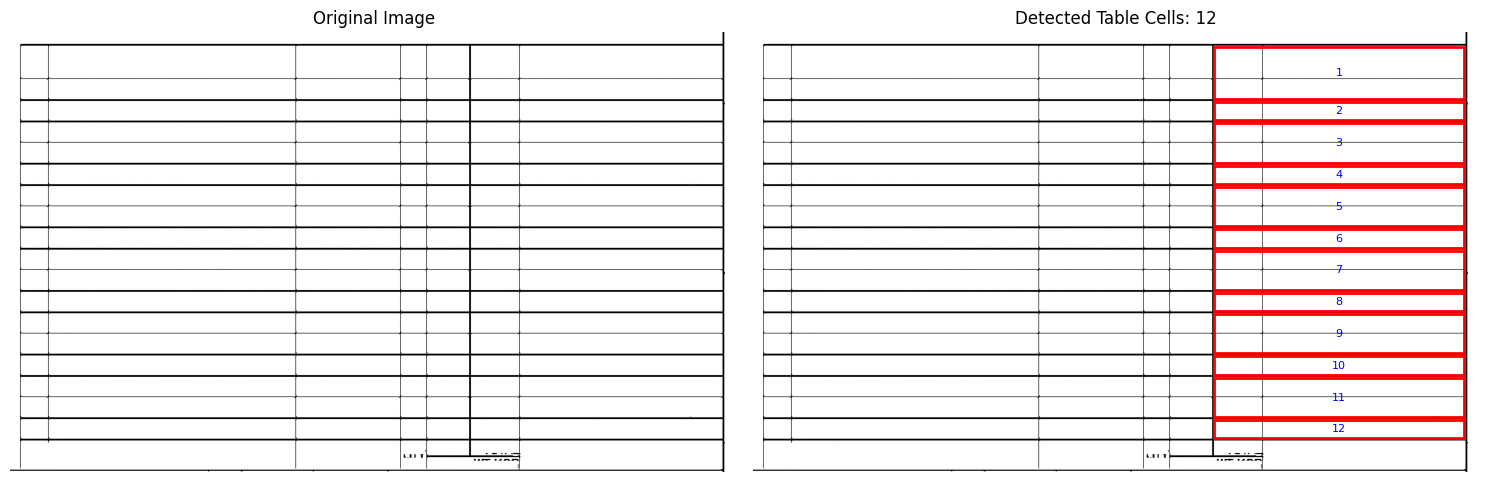

Table analysis complete:
- Detected 12 cells
- Estimated structure: 12 rows × 1 columns


In [141]:
cell_coords, num_rows, num_cols, cell_contents = process_table_image(image_path, output_dir)
    

In [73]:
print(cell_coords)
print(len(cell_coords))

[(0, 0, 1197, 734), (776, 24, 421, 88), (776, 117, 421, 31), (776, 153, 421, 66), (776, 224, 421, 31), (776, 260, 421, 66), (776, 331, 421, 31), (776, 367, 421, 66), (776, 438, 421, 31), (776, 474, 421, 66), (776, 545, 421, 31), (776, 581, 421, 66), (776, 652, 421, 31), (0, 739, 1197, 1)]
14


In [142]:
print(cell_contents)

['—_|__', '|', 'S$', '|', 'S$', '|', 'S$', '|', 'S$', '|', 'S$', '|']


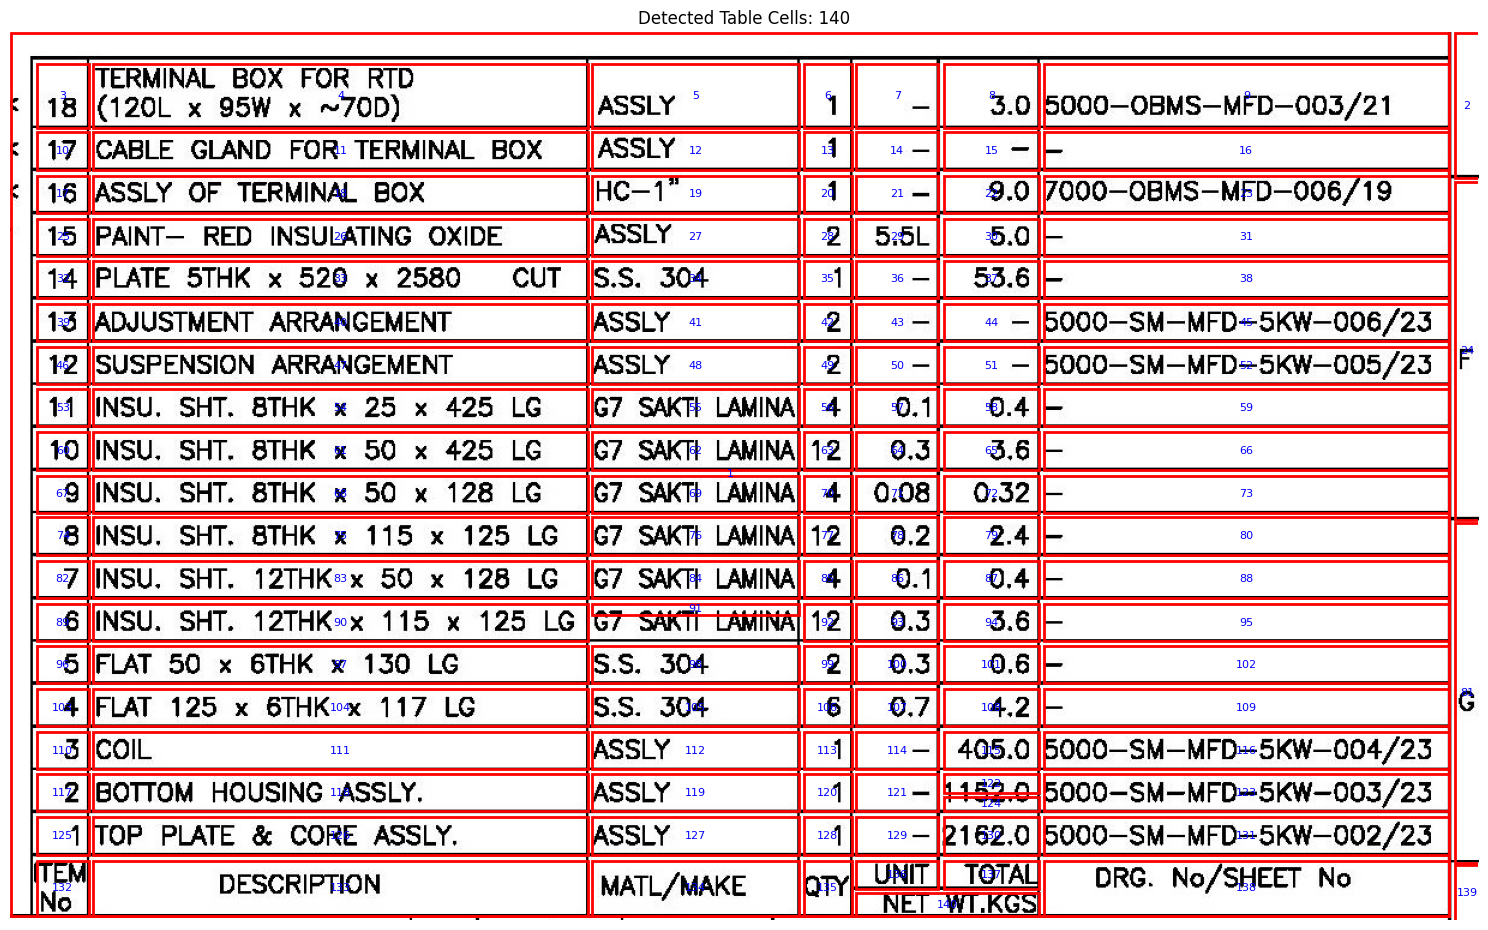

Found 140 cells in the table.
Cell coordinates (x, y, width, height):
Cell 1: (0, 0, 1199, 736)
Cell 2: (1204, 0, 20, 121)
Cell 3: (22, 26, 43, 53)
Cell 4: (69, 26, 412, 53)
Cell 5: (485, 26, 172, 53)
Cell 6: (661, 26, 40, 53)
Cell 7: (705, 26, 68, 53)
Cell 8: (778, 26, 79, 53)
Cell 9: (861, 26, 338, 53)
Cell 10: (22, 83, 43, 31)
Cell 11: (69, 83, 412, 31)
Cell 12: (485, 83, 172, 31)
Cell 13: (661, 83, 40, 31)
Cell 14: (705, 83, 68, 31)
Cell 15: (778, 83, 79, 31)
Cell 16: (861, 83, 338, 31)
Cell 17: (22, 119, 43, 31)
Cell 18: (69, 119, 412, 31)
Cell 19: (485, 119, 172, 31)
Cell 20: (661, 119, 40, 31)
Cell 21: (705, 119, 68, 31)
Cell 22: (778, 119, 79, 31)
Cell 23: (861, 119, 338, 31)
Cell 24: (1204, 124, 20, 282)
Cell 25: (22, 155, 43, 31)
Cell 26: (69, 155, 412, 31)
Cell 27: (485, 155, 172, 31)
Cell 28: (661, 155, 40, 31)
Cell 29: (705, 155, 68, 31)
Cell 30: (778, 155, 79, 31)
Cell 31: (861, 155, 338, 31)
Cell 32: (22, 190, 43, 31)
Cell 33: (69, 190, 412, 31)
Cell 34: (485, 190, 172, 

In [146]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

def extract_table_cells(image_path, output_dir=None, display_results=True):
    """
    Extract coordinates of all table cells from engineering parts list tables.
    
    Args:
        image_path (str): Path to the input image
        output_dir (str, optional): Directory to save output files
        display_results (bool): Whether to display the detected cells visually
    
    Returns:
        list: List of tuples (x, y, w, h) for each detected table cell
    """
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Get image dimensions
    height, width = img.shape[:2]
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold to get binary image
    # For engineering drawings, adaptive thresholding often works better
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv2.THRESH_BINARY_INV, 11, 2)
    
    # Remove noise
    kernel = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # Create horizontal and vertical kernels for line detection
    # Adjust these based on your specific table dimensions
    # h_kernel_size = width // 30  # Horizontal kernel
    # v_kernel_size = height // 30  # Vertical kernel

    h_kernel_size = 25  # Horizontal kernel
    v_kernel_size = 25  # Vertical kernel
    
    h_kernel = np.ones((1, h_kernel_size), np.uint8)
    v_kernel = np.ones((v_kernel_size, 1), np.uint8)
    
    # Detect horizontal lines
    horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, h_kernel)
    horizontal_lines = cv2.dilate(horizontal_lines, np.ones((1, 5), np.uint8), iterations=2)
    
    # Detect vertical lines
    vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, v_kernel)
    vertical_lines = cv2.dilate(vertical_lines, np.ones((5, 1), np.uint8), iterations=2)
    
    # Combine horizontal and vertical lines to get the table grid
    table_grid = cv2.bitwise_or(horizontal_lines, vertical_lines)
    
    # Alternative approach using Hough lines for better detection
    line_min_width = 15  # Minimum line width to detect
    
    # Detect lines using Hough transform with parameters tuned for table lines
    lines = cv2.HoughLinesP(
        binary, 
        rho=1,                    # Distance resolution (1 pixel)
        theta=np.pi/180,          # Angle resolution (1 degree)
        threshold=100,            # Min number of points to form a line
        minLineLength=width/5,    # Min line length - adjusted for table cells
        maxLineGap=20             # Max allowed gap between line segments
    )
    
    # Create a blank image to draw the detected lines
    hough_lines = np.zeros_like(binary)
    
    if lines is not None:
        # Separate horizontal and vertical lines
        h_lines = []
        v_lines = []
        
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Calculate angle to determine if horizontal or vertical
            angle = np.abs(np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi)
            
            # Horizontal lines
            if angle < 20 or angle > 160:
                h_lines.append((min(x1, x2), y1 if x1 < x2 else y2, 
                               max(x1, x2), y1 if x1 > x2 else y2))
                cv2.line(hough_lines, (x1, y1), (x2, y2), 255, 2)
            
            # Vertical lines
            elif angle > 70 and angle < 110:
                v_lines.append((x1 if y1 < y2 else x2, min(y1, y2), 
                               x1 if y1 > y2 else x2, max(y1, y2)))
                cv2.line(hough_lines, (x1, y1), (x2, y2), 255, 2)
    
    # Combine approaches for more robust detection
    combined_grid = cv2.bitwise_or(table_grid, hough_lines)
    
    # Invert the grid to get cell regions
    grid_inverted = cv2.bitwise_not(combined_grid)
    
    # Apply morphological operations to clean up
    cleaned_grid = cv2.morphologyEx(grid_inverted, cv2.MORPH_OPEN, kernel)
    
    # Find connected components (cells)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned_grid)
    
    # Filter out the background and small regions
    # Engineering tables typically have large, well-defined cells
    min_cell_area = 300  # Minimum area threshold for engineering drawings
    max_cell_area = width * height * 0.5  # Max area threshold (50% of image)
    
    cell_coords = []
    for i in range(1, n_labels):  # Skip the first label (background)
        x, y, w, h, area = stats[i]
        
        # Skip cells that are too small or too large
        if area < min_cell_area or area > max_cell_area:
            continue
            
        # Additional filtering to avoid non-cell regions
        # Skip very thin regions (likely not cells)
        aspect_ratio = max(w, h) / (min(w, h) + 0.01)  # Avoid division by zero
        if aspect_ratio > 20:  # Extremely elongated shape
            continue
            
        cell_coords.append((x, y, w, h))
    
    # For engineering tables, we can apply structural analysis to improve detection
    # Group cells by rows based on y-coordinate proximity
    def group_by_rows(coords, y_threshold=10):
        if not coords:
            return []
            
        # Sort by y-coordinate
        sorted_coords = sorted(coords, key=lambda c: c[1])
        
        rows = []
        current_row = [sorted_coords[0]]
        
        for cell in sorted_coords[1:]:
            # If this cell is close enough to the previous row, add it
            if abs(cell[1] - current_row[0][1]) <= y_threshold:
                current_row.append(cell)
            else:
                # Sort cells in the row by x-coordinate
                rows.append(sorted(current_row, key=lambda c: c[0]))
                current_row = [cell]
                
        # Add the last row
        if current_row:
            rows.append(sorted(current_row, key=lambda c: c[0]))
            
        return rows
    
    # Group cells into rows
    cell_rows = group_by_rows(cell_coords)
    
    # Flatten the grouped rows
    organized_cells = [cell for row in cell_rows for cell in row]
    
    # Optionally display results
    if display_results:
        # Create figure with subplots
        fig, ax = plt.subplots(1, 1, figsize=(15, 10))
        
        # Show original image with detected cells
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f'Detected Table Cells: {len(organized_cells)}')
        
        # Add rectangle for each cell
        for i, (x, y, w, h) in enumerate(organized_cells):
            rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            # Add cell number
            ax.text(x + w/2, y + h/2, str(i+1), color='blue', fontsize=8, 
                   ha='center', va='center')
        
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Save the results if output directory is provided
    if output_dir:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        # Save original image with cell rectangles
        result_img = img.copy()
        for i, (x, y, w, h) in enumerate(organized_cells):
            cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 0, 255), 2)
            cv2.putText(result_img, str(i+1), (x+w//2, y+h//2), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
            
        cv2.imwrite(os.path.join(output_dir, 'detected_cells.png'), result_img)
        
        # Save coordinates to a text file
        with open(os.path.join(output_dir, 'cell_coordinates.txt'), 'w') as f:
            f.write("Cell Coordinates (x, y, width, height):\n")
            for i, (x, y, w, h) in enumerate(organized_cells):
                f.write(f"Cell {i+1}: ({x}, {y}, {w}, {h})\n")
    
    return organized_cells

def analyze_engineering_table(image_path, output_dir=None):
    """
    Complete analysis of engineering table including structure and coordinates.
    
    Args:
        image_path (str): Path to the input image
        output_dir (str, optional): Directory to save output files
        
    Returns:
        tuple: (cell_coordinates, cell_rows, cell_columns)
    """
    # Extract cell coordinates
    cell_coords = extract_table_cells(image_path, output_dir, display_results=True)
    
    # Analyze table structure
    # Sort cells by y-coordinate, then by x-coordinate
    sorted_cells = sorted(cell_coords, key=lambda c: (c[1], c[0]))
    
    # Determine rows and columns
    y_positions = {}
    x_positions = {}
    
    for x, y, w, h in sorted_cells:
        # Group by y position (rows)
        y_center = y + h/2
        row_found = False
        for y_pos in y_positions:
            if abs(y_center - y_pos) < 20:  # Adjust threshold based on your table
                y_positions[y_pos].append((x, y, w, h))
                row_found = True
                break
        if not row_found:
            y_positions[y_center] = [(x, y, w, h)]
            
        # Group by x position (columns)
        x_center = x + w/2
        col_found = False
        for x_pos in x_positions:
            if abs(x_center - x_pos) < 20:  # Adjust threshold based on your table
                x_positions[x_pos].append((x, y, w, h))
                col_found = True
                break
        if not col_found:
            x_positions[x_center] = [(x, y, w, h)]
    
    # Sort rows and columns by position
    rows = [cells for _, cells in sorted(y_positions.items(), key=lambda i: i[0])]
    columns = [cells for _, cells in sorted(x_positions.items(), key=lambda i: i[0])]
    
    # Print table structure information
    print(f"Table Analysis Results:")
    print(f"- Total cells detected: {len(cell_coords)}")
    print(f"- Number of rows: {len(rows)}")
    print(f"- Number of columns: {len(columns)}")
    
    if output_dir:
        with open(os.path.join(output_dir, 'table_analysis.txt'), 'w') as f:
            f.write(f"Table Analysis Results:\n")
            f.write(f"- Total cells detected: {len(cell_coords)}\n")
            f.write(f"- Number of rows: {len(rows)}\n")
            f.write(f"- Number of columns: {len(columns)}\n")
    
    return cell_coords, rows, columns

# Example usage
if __name__ == "__main__":
    # Replace with your image path
    #image_path = "engineering_table.png"
    #output_dir = "table_results"

    image_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/SM-MFD-5KW-001-23.jpg"
    output_dir = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/table_3/.jpg"
    
    # Extract cell coordinates only
    cell_coords = extract_table_cells(image_path, output_dir)
    
    print(f"Found {len(cell_coords)} cells in the table.")
    print("Cell coordinates (x, y, width, height):")
    for i, (x, y, w, h) in enumerate(cell_coords):
        print(f"Cell {i+1}: ({x}, {y}, {w}, {h})")
    
    # Or run complete analysis
    # analyze_engineering_table(image_path, output_dir)

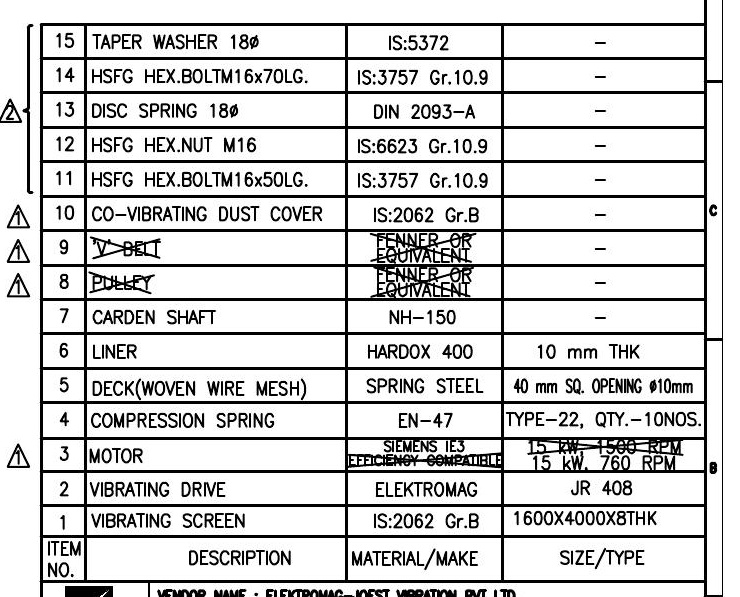

740 , 740 , 740
[array([[         27,          24,           5,         172],
       [        722,           0,           3,         597],
       [         40,           0,         669,         597],
       [        505,         539,         200,          42],
       [        349,         539,         153,          42],
       [         88,         539,         258,          42],
       [         44,         539,          41,          42],
       [        505,         508,         200,          28],
       [        349,         508,         153,          28],
       [         88,         508,         258,          28],
       [         44,         508,          41,          28],
       [        505,         474,         200,          31],
       [        349,         474,         153,          31],
       [         88,         474,         258,          31],
       [         44,         474,          41,          31],
       [        505,         441,         200,          30],
       

In [148]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1171.jpg"
pred_bom = cv2.imread(pred_bom_id)

boxes_list, _, _, _= all_boxes(pred_bom)
print(boxes_list)

In [151]:
print(boxes_list[0])
print(type(boxes_list[0]))
print(boxes_list[0].shape)

[[         27          24           5         172]
 [        722           0           3         597]
 [         40           0         669         597]
 [        505         539         200          42]
 [        349         539         153          42]
 [         88         539         258          42]
 [         44         539          41          42]
 [        505         508         200          28]
 [        349         508         153          28]
 [         88         508         258          28]
 [         44         508          41          28]
 [        505         474         200          31]
 [        349         474         153          31]
 [         88         474         258          31]
 [         44         474          41          31]
 [        505         441         200          30]
 [        349         441         153          30]
 [         88         441         258          30]
 [         44         441          41          30]
 [        505         405      

In [152]:
def remove_before_last_zero(arr_list):
    """Removes all rows before the last occurrence of zero in the second column for each array."""
    processed_list = []
    
    for arr in arr_list:
        # Find all indices where the second column is zero
        zero_indices = np.where(arr[:, 1] == 0)[0]
        
        if zero_indices.size > 0:  # Ensure there's at least one zero
            last_zero_idx = zero_indices[-1]  # Get the last occurrence of zero
            processed_list.append(arr[last_zero_idx + 1:])  # Keep data from the next row onwards
    
    return processed_list

In [153]:
bom_boxes = remove_before_last_zero(boxes_list)
print(bom_boxes)

[array([[        505,         539,         200,          42],
       [        349,         539,         153,          42],
       [         88,         539,         258,          42],
       [         44,         539,          41,          42],
       [        505,         508,         200,          28],
       [        349,         508,         153,          28],
       [         88,         508,         258,          28],
       [         44,         508,          41,          28],
       [        505,         474,         200,          31],
       [        349,         474,         153,          31],
       [         88,         474,         258,          31],
       [         44,         474,          41,          31],
       [        505,         441,         200,          30],
       [        349,         441,         153,          30],
       [         88,         441,         258,          30],
       [         44,         441,          41,          30],
       [        505,   